In [2]:
EMA_path = "./../inference/combined/EMA_manually_cleaned.json"
JAPAN_path = "./../inference/combined/JAPAN_manually_cleaned.json"
SWISSMEDIC_path = "./../inference/combined/SWISSMEDIC_manually_cleaned.json"
AUSTRALIA_path = "./../inference/combined/AUSTRALIA_manually_cleaned.json"
FDA_path = "./../inference/combined/FDA_manually_cleaned.json"
HEALTHCANADA_path = "./../inference/combined/HEALTHCANADA_manually_cleaned.json"

SAVE_DIR = "./../inference/combined/figures/"
import os
os.makedirs(SAVE_DIR, exist_ok=True)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.colors as mcolors
import seaborn as sns
import json
import numpy as np
from matplotlib.ticker import FixedLocator, ScalarFormatter
import math

In [3]:
def load_data(file_path):
    """Load data from a JSON file."""
    with open(file_path, 'r', encoding="utf-8") as file:
        data = json.load(file)
    return pd.DataFrame(data)

def to_lower(df):
    return df.map(lambda x: x.lower().strip() if isinstance(x, str) else x)

def remove_invalid_rows(df):
    invalid_rows = df.apply(lambda x: x.astype(str).str.contains("the response is not valid json", case=False, na=False))
    print(f"Total rows with invalid responses: {invalid_rows.any(axis=1).sum()}")
    df = df[~invalid_rows.any(axis=1)]
    return df

def prepare_for_analysis(filepath):
    df = load_data(filepath)
    df = df.transpose()
    df.replace(["not reported", "Not reported", ""], np.nan, inplace=True)
    df = remove_invalid_rows(df)
    df = to_lower(df)
    return df

def generate_distinct_colors(n, cmap_name='tab20'):
    cmap = cm.get_cmap(cmap_name, n)
    return [mcolors.rgb2hex(cmap(i)) for i in range(n)]

def date_to_int(df, col_name):
    df = df.copy()
    original_len = len(df)

    # 1) Versuchen, direkt als Zahl zu interpretieren
    numeric_years = pd.to_numeric(df[col_name], errors='coerce')

    # 2) Nur plausible Jahreszahlen behalten
    numeric_years = numeric_years.where(numeric_years.between(1800, 2100))

    # 3) Falls kein valider Jahrwert -> als Datum interpretieren
    dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year

    # 4) Jahreswerte bevorzugen, sonst Datum-Jahr nehmen
    df[col_name] = numeric_years.fillna(dt_years).astype('Int64')

    # 5) Ungültige Werte entfernen
    df = df.dropna(subset=[col_name])
    df[col_name] = df[col_name].astype(int)

    final_len = len(df)
    print(f"Original length: {original_len}, Final length after cleaning: {final_len}, "
          f"Percentage kept: {final_len/original_len*100:.2f}%")
    return df

def set_early_years_to_cutoff(df, cols=None, cutoff=None, replace_with=None):
    """
    Replace any year < cutoff found in the given columns with replace_with.
    - If column name contains 'date', replaced values become Timestamp(f'{replace_with}-01-01').
    - If column looks like a 'year' column, replaced values become int(replace_with).
    Returns a copy of df and a dict with counts per column of replacements made.
    """
    d = df.copy()
    if cols is None:
        # default: any column containing 'year' or 'date' in its name
        cols = [c for c in d.columns if ('year' in c.lower()) or ('date' in c.lower())]

    stats = {}
    for col in cols:
        if col not in d.columns:
            stats[col] = {'found': False, 'replaced': 0}
            continue

        ser = d[col]
        # 1) attempt numeric year extraction
        numeric = pd.to_numeric(ser, errors='coerce')

        # 2) fallback to datetime->year
        dt_year = pd.to_datetime(ser, errors='coerce', infer_datetime_format=True).dt.year

        # 3) choose numeric where available else dt_year
        years = numeric.fillna(dt_year)

        # mask: valid year and less than cutoff
        mask = years.notna() & (years.astype('Int64') < cutoff)
        n_replace = int(mask.sum())

        if n_replace > 0:
            if 'date' in col.lower():
                # replace with first day of replace year as Timestamp
                replacement = pd.to_datetime(f"{int(replace_with)}-01-01")
            else:
                replacement = int(replace_with)

            # assign replacement (keep dtype flexible)
            d.loc[mask.index[mask], col] = replacement

        stats[col] = {'found': True, 'replaced': n_replace}
    return d, stats

def plot_timeline(df, col_name, dataset_name=None):
    df = date_to_int(df, col_name)  # Ensure column is integer (e.g., year)
    unique_vals = sorted(df[col_name].unique())
    bins = np.append(unique_vals, unique_vals[-1] + 1)
    plt.figure(figsize=(8, 4))
    ax = plt.gca()
    counts, edges, patches = plt.hist(df[col_name], bins=bins, color="seagreen", edgecolor='black', align='left', alpha=0.7)
    ax.set_xticks(unique_vals)
    ax.set_xticklabels([str(int(x)) for x in unique_vals], rotation=45, ha='center')
    plt.xlabel(col_name)
    plt.ylabel('Frequency')
    plt.title(dataset_name)
    plt.grid(axis='y', linestyle='--', alpha=0.7, color='silver')
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}timeline_{col_name}_{dataset_name}.png", dpi=300, bbox_inches='tight')
    plt.close()

def plot_drug_class_per_application_year_absolute(df, date_col='Application_date', drug_class_colormap=None, dataset_name=None):
    # preprocessing
    df = df.replace(["not reported", "Not reported", "", np.nan], np.nan)
    df = df.dropna(subset=['Drug_class', date_col])
    df = df[~df['Drug_class'].astype(str).str.contains('error: pycryptodome', case=False, na=False)]

    # date -> year
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df = df.dropna(subset=[date_col])
    df['Year'] = df[date_col].dt.year.astype(int)

    # grouping
    count_df = df.groupby(['Year', 'Drug_class']).size().unstack(fill_value=0)

    # Ensure colormap is complete
    if drug_class_colormap is None:
        colors = generate_distinct_colors(len(count_df.columns), cmap_name='nipy_spectral')
    else:
        colors = [drug_class_colormap.get(cls, '#333333') for cls in count_df.columns]

    # Plot
    count_df.plot(
        kind='bar',
        stacked=True,
        figsize=(10, 5),
        color=colors,
        edgecolor='black'
    )

    plt.ylabel('Number of Drugs')
    plt.xlabel('Year')
    plt.title(dataset_name)
    plt.legend(title='Drug Class', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    if dataset_name:
        plt.savefig(f"{SAVE_DIR}drug_class_per_application_year_absolute_{dataset_name}.png", dpi=300, bbox_inches='tight')

def plot_drug_class_per_decision_year_absolute(df, year_col='Decision_year', drug_class_colormap=None, dataset_name=None):
    # Vorverarbeitung
    df = df.replace(["not reported", "Not reported", "", np.nan], np.nan)
    df = df.dropna(subset=['Drug_class', year_col])
    df = df[~df['Drug_class'].astype(str).str.contains('error: pycryptodome', case=False, na=False)]

    # Decision_year -> Year (int) mit deiner date_to_int-Funktion
    df = date_to_int(df, year_col)
    df.rename(columns={year_col: 'Year'}, inplace=True)

    # Gruppierung (Jahre sortieren)
    count_df = (
        df.groupby(['Year', 'Drug_class'])
          .size()
          .unstack(fill_value=0)
          .sort_index()
    )

    # Farbzuordnung
    if drug_class_colormap is None:
        colors = generate_distinct_colors(len(count_df.columns), cmap_name='nipy_spectral')
    else:
        colors = [drug_class_colormap.get(cls, '#333333') for cls in count_df.columns]

    # Plot
    ax = count_df.plot(
        kind='bar',
        stacked=True,
        figsize=(10, 5),
        color=colors,
        edgecolor='black'
    )

    ax.set_ylabel('Number of Drugs')
    ax.set_xlabel('Year')
    ax.set_title(dataset_name)
    ax.legend(title='Drug Class', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    if dataset_name:
        plt.savefig(f"{SAVE_DIR}drug_class_per_decision_year_absolute_{dataset_name}.png",
                    dpi=300, bbox_inches='tight')

def plot_drug_class_per_year(df, date_col=None, drug_class_colormap=None, dataset_name=None):
    # Vorverarbeitung
    df = df.copy()
    df = df.replace(["not reported", "Not reported", "", np.nan], np.nan)
    df = df.dropna(subset=['Drug_class', date_col])
    df = df[~df['Drug_class'].astype(str).str.contains('error: pycryptodome', case=False, na=False)]

    # Datum/Jahr mit deiner Hilfsfunktion robust auf Integer-Jahre mappen
    df = date_to_int(df, date_col)             # -> col wird int-Jahr
    df = df.rename(columns={date_col: 'Year'}) # konsistent weiterarbeiten

    # Gruppieren
    count_df = (
        df.groupby(['Year', 'Drug_class'])
          .size()
          .unstack(fill_value=0)
          .sort_index()
    )

    # Auf 100% normalisieren (Zeilenweise)
    denom = count_df.sum(axis=1).replace(0, np.nan)
    percent_df = (count_df.T / denom).T.fillna(0) * 100

    # Farben
    if drug_class_colormap is None:
        colors = generate_distinct_colors(len(percent_df.columns), cmap_name='nipy_spectral')
    else:
        colors = [drug_class_colormap.get(cls, '#333333') for cls in percent_df.columns]

    # Plot
    ax = percent_df.plot(
        kind='bar',
        stacked=True,
        figsize=(10, 5),
        color=colors,
        edgecolor='black'
    )
    ax.set_ylabel('Drugs, normalized (%)')
    ax.set_xlabel('Year')
    ax.set_title(dataset_name)
    ax.legend(title='Drug Class', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # X-Achse explizit als Integer-Jahre labeln (verhindert 2008.0)
    ax.set_xticks(range(len(percent_df.index)))
    ax.set_xticklabels([str(int(y)) for y in percent_df.index], rotation=45, ha='right')

    plt.tight_layout()
    if dataset_name:
        plt.savefig(f"{SAVE_DIR}drug_class_per_year_stacked_{date_col}_{dataset_name}.png", dpi=300, bbox_inches='tight')

def plot_drug_class_distribution_pie(df, drug_class_colormap=None, dataset_name=None):
    df = df.copy()
    df = df.replace(["not reported", "Not reported", "", np.nan], np.nan)
    df = df.dropna(subset=['Drug_class'])
    df = df[~df['Drug_class'].astype(str).str.contains('error: pycryptodome', case=False, na=False)]

    class_counts = df['Drug_class'].value_counts()
    labels = class_counts.index
    sizes = class_counts.values

    # Ensure colormap is complete
    if drug_class_colormap is None:
        drug_class_colormap = {}
    cmap = plt.get_cmap('tab20')
    for i, label in enumerate(labels):
        if label not in drug_class_colormap:
            drug_class_colormap[label] = cmap(i % cmap.N)

    colors = [drug_class_colormap[label] for label in labels]
    total = sizes.sum()

    plt.figure(figsize=(5, 5))
    wedges, _ = plt.pie(
        sizes,
        startangle=140,
        colors=colors,
        wedgeprops=dict(width=0.3, edgecolor='w'),
    )
    legend_labels = [f"{label} ({size / total * 100:.1f}%)" for label, size in zip(labels, sizes)]

    plt.title(dataset_name)

    plt.legend(
        wedges,
        legend_labels,
        title='Drug Class',
        loc='center left',
        bbox_to_anchor=(1, 0.7),
        fontsize=9
    )
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}drug_class_distribution_pie_{dataset_name}.png", dpi=300, bbox_inches='tight')

def plot_drug_class_by_administration_route(df, dataset_name=None):
    df = df.copy()
    
    # Preprocessing
    df = df.replace(["not reported", "Not reported", "", np.nan], np.nan)
    df = df.dropna(subset=['Drug_class', 'Administration_route'])
    df = df[~df['Drug_class'].astype(str).str.contains('error: pycryptodome', case=False, na=False)]

    # split administration routes and clean whitespace
    df['Administration_route'] = df['Administration_route'].str.replace('„|“|”', '"')  # typografische Anführungszeichen entfernen
    df['Administration_route'] = df['Administration_route'].str.split(';')
    df = df.explode('Administration_route')
    df['Administration_route'] = df['Administration_route'].str.strip()

    # Count occurrences of drug classes by administration route
    class_counts = df.groupby(['Drug_class', 'Administration_route']).size().unstack(fill_value=0)
    class_counts = class_counts.loc[class_counts.sum(axis=1).sort_values(ascending=False).index]

    # Farben generieren mit generate_distinct_colors
    colors = generate_distinct_colors(len(class_counts.index), cmap_name='nipy_spectral')

    # Plot
    class_counts.plot(
        kind='bar',
        stacked=True,
        color=colors,
        edgecolor='black',
        figsize=(10, 6)
    )

    plt.xlabel('Drug Class')
    plt.ylabel('Number of Drugs')
    plt.legend(title='Administration Route', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7, color='silver')
    plt.tight_layout()

    if dataset_name:
        plt.savefig(f"{SAVE_DIR}drug_class_by_administration_route_{dataset_name}.png", dpi=300, bbox_inches='tight')

def plot_administration_route_per_year(df, agency_name, date_col='Application_date', admin_route_colormap=None, dataset_name=None):
    df = df.copy()
    
    # preprocessing
    df = df.replace(["not reported", "Not reported", "", np.nan], np.nan)
    df = df.dropna(subset=['Administration_route', date_col])
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df = df.dropna(subset=[date_col])
    df['Year'] = df[date_col].dt.year.astype(int)

    # if multiple administration routes are separated by ';'
    df['Administration_route'] = df['Administration_route'].str.replace('„|“|“', '"')  # typografische Anführungszeichen entfernen
    df['Administration_route'] = df['Administration_route'].str.split(';')
    df = df.explode('Administration_route')
    df['Administration_route'] = df['Administration_route'].str.strip()

    ##################################
    top10 = (df['Administration_route'].str.split(';').explode().str.strip()
            .value_counts().nlargest(10).index.tolist())
    df_exploded = df.assign(Administration_route=df['Administration_route'].str.split(';')).explode('Administration_route')
    df = df_exploded[df_exploded['Administration_route'].str.strip().isin(top10)]
    ######################################

    # Ggroup and normalize
    count_df = df.groupby(['Year', 'Administration_route']).size().unstack(fill_value=0)
    percent_df = count_df.div(count_df.sum(axis=1), axis=0) * 100  # auf 100% normieren

    # Use global colormap if provided
    if admin_route_colormap is not None:
        colors = [admin_route_colormap.get(route, '#CCCCCC') for route in percent_df.columns]
    else:
        cmap = plt.get_cmap('tab20', len(percent_df.columns))
        colors = [cmap(i) for i in range(len(percent_df.columns))]

    # Plot
    percent_df.plot(
        kind='bar',
        stacked=True,
        figsize=(10, 5),
        color=colors,
        edgecolor='black'
    )
    plt.title(agency_name)
    plt.xlabel('Year')
    plt.ylabel('Drugs, normalized (%)')
    plt.legend(title='Administration Route\n(top 10 by frequency)', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    if dataset_name:
        plt.savefig(f"{SAVE_DIR}administration_route_per_year_{dataset_name}.png", dpi=300, bbox_inches='tight')

def plot_drug_class_by_pharmaceutical_form(df, pharma_form_colormap=None, dataset_name=None):
    df = df.copy()
    
    # Preprocessing
    df = df.replace(["not reported", "Not reported", "", np.nan], np.nan)
    df = df.dropna(subset=['Drug_class', 'Pharmaceutical_form'])
    df = df[~df['Drug_class'].astype(str).str.contains('error: pycryptodome', case=False, na=False)]

    # Split pharmaceutical forms and clean whitespace
    df['Pharmaceutical_form'] = df['Pharmaceutical_form'].str.replace('„|“|”', '"')  # typografische Anführungszeichen entfernen
    df['Pharmaceutical_form'] = df['Pharmaceutical_form'].str.split(';')
    df = df.explode('Pharmaceutical_form')
    df['Pharmaceutical_form'] = df['Pharmaceutical_form'].str.strip()

    ##################################
    top10 = (df['Pharmaceutical_form'].str.split(';').explode().str.strip()
            .value_counts().nlargest(10).index.tolist())
    df_exploded = df.assign(Pharmaceutical_form=df['Pharmaceutical_form'].str.split(';')).explode('Pharmaceutical_form')
    df = df_exploded[df_exploded['Pharmaceutical_form'].str.strip().isin(top10)]
    ######################################

    # Count occurrences of drug classes by pharmaceutical form
    class_counts = df.groupby(['Drug_class', 'Pharmaceutical_form']).size().unstack(fill_value=0)
    class_counts = class_counts.loc[class_counts.sum(axis=1).sort_values(ascending=False).index]
    # normalize to 100%
    percent_df = class_counts.div(class_counts.sum(axis=1), axis=0) * 100  # auf 100% normieren

    # Use global colormap if provided
    if pharma_form_colormap is not None:
        colors = [pharma_form_colormap.get(form, '#CCCCCC') for form in class_counts.columns]
    else:
        colors = generate_distinct_colors(len(class_counts.columns))

    # Plot
    percent_df.plot(
        kind='bar',
        stacked=True,
        color=colors,
        edgecolor='black',
        figsize=(10, 6)
    )

    plt.xlabel('Drug Class')
    plt.ylabel('Drugs, normalized (%)')
    plt.title(dataset_name)
    plt.legend(title='Pharmaceutical Form', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7, color='silver')
    plt.tight_layout()

    if dataset_name:
        plt.savefig(f"{SAVE_DIR}drug_class_by_pharmaceutical_form_{dataset_name}.png", dpi=300, bbox_inches='tight')

def plot_pharmaceutical_form_per_year(df, agency_name, date_col=None, pharma_form_colormap=None, dataset_name=None):
    df = df.copy()

    # preprocessing
    df = df.replace(["not reported", "Not reported", "", np.nan], np.nan)
    df = df.dropna(subset=['Pharmaceutical_form', date_col])
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df = df.dropna(subset=[date_col])
    df['Year'] = df[date_col].dt.year.astype(int)

    # if multiple pharmaceutical forms are separated by ';'
    df['Pharmaceutical_form'] = df['Pharmaceutical_form'].str.replace('„|“|“', '"')  # typografische Anführungszeichen entfernen
    df['Pharmaceutical_form'] = df['Pharmaceutical_form'].str.split(';')
    df = df.explode('Pharmaceutical_form')
    df['Pharmaceutical_form'] = df['Pharmaceutical_form'].str.strip()

    ##################################
    top10 = (df['Pharmaceutical_form'].str.split(';').explode().str.strip()
            .value_counts().nlargest(10).index.tolist())
    df_exploded = df.assign(Pharmaceutical_form=df['Pharmaceutical_form'].str.split(';')).explode('Pharmaceutical_form')
    df = df_exploded[df_exploded['Pharmaceutical_form'].str.strip().isin(top10)]
    ######################################

    # group and normalize
    count_df = df.groupby(['Year', 'Pharmaceutical_form']).size().unstack(fill_value=0)
    percent_df = count_df.div(count_df.sum(axis=1), axis=0) * 100  # auf 100% normieren

    # Use global colormap if provided
    if pharma_form_colormap is not None:
        colors = [pharma_form_colormap.get(form, '#CCCCCC') for form in percent_df.columns]
    else:
        colors = generate_distinct_colors(len(percent_df.columns), cmap_name='tab20')

    # Plot
    percent_df.plot(
        kind='bar',
        stacked=True,
        figsize=(10, 5),
        color=colors,
        edgecolor='black'
    )
    plt.title(agency_name)
    plt.xlabel('Year')
    plt.ylabel('Drugs, normalized (%)')
    plt.legend(title='Pharmaceutical Form', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    if dataset_name:
        plt.savefig(f"{SAVE_DIR}pharmaceutical_form_per_year_{date_col}_{dataset_name}.png", dpi=300, bbox_inches='tight')

def plot_disease_class_per_decision_year_absolute(
    df, year_col=None, disease_class_colormap=None, dataset_name=None
):
    disease_col = 'Disease_class(es)'

    # Vorverarbeitung
    df = df.replace(["not reported", "Not reported", "", np.nan], np.nan)
    df = df.dropna(subset=[disease_col, year_col])
    df = df[~df[disease_col].astype(str).str.contains('error: pycryptodome', case=False, na=False)]

    # Decision_year -> Year (int) mit deiner date_to_int-Funktion
    df = date_to_int(df, year_col)
    df.rename(columns={year_col: 'Year'}, inplace=True)

    # Mehrfachangaben aufsplitten
    df[disease_col] = df[disease_col].astype(str).str.split(';')
    df = df.explode(disease_col)
    df[disease_col] = df[disease_col].str.strip()  # Leerzeichen entfernen
    df = df[df[disease_col] != '']  # Leere Werte entfernen

    # Top 2 Disease Classes ausgeben
    top_classes = df[disease_col].value_counts().head(2)
    print("\nTop 2 Disease Classes (absolute Häufigkeit):")
    for cls, count in top_classes.items():
        print(f"{cls}: {count}")

    # Gruppierung (Jahre sortieren)
    count_df = (
        df.groupby(['Year', disease_col])
          .size()
          .unstack(fill_value=0)
          .sort_index()
    )

    # Farbzuordnung mit deiner Funktion
    if disease_class_colormap is None:
        colors = generate_distinct_colors(len(count_df.columns))
    else:
        colors = [disease_class_colormap.get(cls, '#333333') for cls in count_df.columns]

    # Plot
    ax = count_df.plot(
        kind='bar',
        stacked=True,
        figsize=(14, 6),
        color=colors,
        edgecolor='black'
    )

    ax.set_ylabel('Number of Drugs')
    ax.set_xlabel('Year')
    ax.set_title(dataset_name)
    ax.legend(title='Disease Class', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    if dataset_name:
        plt.savefig(f"{SAVE_DIR}disease_class_per_decision_year_absolute_{dataset_name}.png",
                    dpi=300, bbox_inches='tight')

def plot_marketing_holder_distribution_pie(df, data_col=None, holder_colormap=None, dataset_name=None):
    df = df.copy()
    
    # Vorverarbeitung
    df = df.replace(["not reported", "Not reported", "", np.nan], np.nan)
    df = df.dropna(subset=[data_col])
    df = df[~df[data_col].astype(str).str.contains('error: pycryptodome', case=False, na=False)]

    holder_counts = df[data_col].str.strip().str.lower().value_counts()

    if len(holder_counts) > 20:
        top_counts = holder_counts.nlargest(20)
        others_labels = holder_counts.iloc[20:].index.tolist()
        others_count = len(others_labels)

        # Append 'Other' category
        top_counts['Other'] = others_count
        holder_counts = top_counts

    labels = holder_counts.index
    sizes = holder_counts.values

    # Ensure colormap is complete
    if holder_colormap is None:
        holder_colormap = {}
    cmap = plt.get_cmap('tab20')
    for i, label in enumerate(labels):
        if label not in holder_colormap:
            holder_colormap[label] = cmap(i % cmap.N)

    colors = [holder_colormap[label] for label in labels]
    total = sizes.sum()

    plt.figure(figsize=(10, 5))
    wedges, _ = plt.pie(
        sizes,
        startangle=140,
        colors=colors,
        wedgeprops=dict(width=0.3, edgecolor='w'),
    )

    legend_labels = []
    for label, size in zip(labels, sizes):
        if label == 'Other':
            legend_labels.append(f"Other ({size} unique holders, {size / total * 100:.1f}%)")
        else:
            legend_labels.append(f"{label} ({size / total * 100:.1f}%)")

    plt.legend(
        wedges,
        legend_labels,
        title='Marketing Authorisation Holder',
        loc='center left',
        bbox_to_anchor=(1, 0.7),
        fontsize=9
    )
    plt.title(dataset_name)
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}marketing_holder_distribution_pie_{dataset_name}.png", dpi=300, bbox_inches='tight')

def plot_review_duration_by_agency(agency_dfs: dict, submission_col='Application_date', decision_col='Decision_date', dataset_name=None):
   
    combined_list = []

    # calculate review duration for each agency
    for agency, df in agency_dfs.items(): 
        if "Application_date" in df.columns and "Decision_date" in df.columns:
            df = df.copy()
            df[submission_col] = pd.to_datetime(df[submission_col], errors='coerce', dayfirst=True)
            df[decision_col] = pd.to_datetime(df[decision_col], errors='coerce', dayfirst=True)
            
            # Calculate duration
            df['Review_duration_days'] = (df[decision_col] - df[submission_col]).dt.days
            
            # Keep only valid positive durations
            valid = df[(df['Review_duration_days'] > 0) & (~df['Review_duration_days'].isna())]
            
            # Check if Nonclinical_abridged column exists and has valid data
            if 'Nonclinical_abridged' in valid.columns:
                valid['Nonclinical_abridged'] = valid['Nonclinical_abridged'].str.lower().str.strip()
                # Create separate entries for abridged and non-abridged
                abridged = valid[valid['Nonclinical_abridged'] == 'yes'].copy()
                non_abridged = valid[valid['Nonclinical_abridged'] == 'no'].copy()
                
                if len(abridged) > 0:
                    abridged['Agency'] = f"{agency} (Abridged)"
                    combined_list.append(abridged[['Review_duration_days', 'Agency']])
                
                if len(non_abridged) > 0:
                    non_abridged['Agency'] = f"{agency} (Non-Abridged)"
                    combined_list.append(non_abridged[['Review_duration_days', 'Agency']])
            else:
                # No abridged column, use all data
                valid['Agency'] = agency
                combined_list.append(valid[['Review_duration_days', 'Agency']])
        else:
            print(f"{agency}: Missing required columns for review duration calculation.")

    combined_df = pd.concat(combined_list, ignore_index=True)

    # add overall data (with abridged breakdown if available)
    has_abridged = any('Abridged' in agency for agency in combined_df['Agency'].unique())
    if has_abridged:
        # Overall abridged
        overall_abridged = combined_df[combined_df['Agency'].str.contains('Abridged')].copy()
        if len(overall_abridged) > 0:
            overall_abridged['Agency'] = 'Overall (Abridged)'
            combined_df = pd.concat([combined_df, overall_abridged], ignore_index=True)
        
        # Overall non-abridged
        overall_non_abridged = combined_df[combined_df['Agency'].str.contains('Non-Abridged')].copy()
        if len(overall_non_abridged) > 0:
            overall_non_abridged['Agency'] = 'Overall (Non-Abridged)'
            combined_df = pd.concat([combined_df, overall_non_abridged], ignore_index=True)
    else:
        # Simple overall for all data
        overall_df = combined_df.copy()
        overall_df['Agency'] = 'Overall'
        combined_df = pd.concat([combined_df, overall_df], ignore_index=True)

    # Plot
    plt.figure(figsize=(8, 5))
    ax = sns.boxplot(data=combined_df, y='Agency', x='Review_duration_days', palette='tab20', orient='h')
    ax.set_xlabel('Review Duration (days, log scale)')
    ax.set_ylabel('Agency')
    ax.set_xscale("symlog", linthresh=500)
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.xaxis.set_minor_formatter(ScalarFormatter())
    ax.set_xticks([100, 200, 300, 400, 500, 700, 1000, 1500, 2000])
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()

    if dataset_name:
        plt.savefig(f"{SAVE_DIR}review_duration_by_agency_{dataset_name}.png", dpi=300, bbox_inches='tight')

def plot_review_duration_by_disease_class(df, submission_col=None, decision_col=None, dataset_name=None, disease_class_colormap=None, abridged=None):
   
    df = df.copy()
    
    # Filter by abridged status FIRST (before date conversion)
    if abridged is not None and 'Nonclinical_abridged' in df.columns:
        df['Nonclinical_abridged'] = df['Nonclinical_abridged'].str.lower().str.strip()
        if abridged == True:
            df = df[df['Nonclinical_abridged'] == 'yes']
        elif abridged == False:
            df = df[df['Nonclinical_abridged'] == 'no']
    
    df[submission_col] = pd.to_datetime(df[submission_col], errors='coerce', dayfirst=True)
    df[decision_col] = pd.to_datetime(df[decision_col], errors='coerce', dayfirst=True)
    df['Review_duration_days'] = (df[decision_col] - df[submission_col]).dt.days

    # Filter out invalid durations and disease classes
    df = df.dropna(subset=['Review_duration_days', 'Disease_class(es)'])
    df = df[df['Review_duration_days'] > 0]

    # Split disease classes and clean whitespace
    df['Disease_class(es)'] = df['Disease_class(es)'].str.split(';')
    df = df.explode('Disease_class(es)')
    df['Disease_class(es)'] = df['Disease_class(es)'].str.strip()  # clean whitespace

    # Order disease classes by mean review duration (ascending)
    mean_durations = df.groupby('Disease_class(es)')['Review_duration_days'].median().sort_values()
    ordered_diseases = mean_durations.index.tolist()
    
    # Map colors using the global colormap (in the sorted order)
    if disease_class_colormap is not None:
        palette = [disease_class_colormap.get(disease, '#CCCCCC') for disease in ordered_diseases]
    else:
        # Fallback to tab20 if no colormap provided
        palette = 'tab20'

    # Determine title suffix based on abridged filter
    title_suffix = ""
    filename_suffix = ""
    if abridged is True:
        title_suffix = " (Abridged)"
        filename_suffix = "_abridged"
    elif abridged is False:
        title_suffix = " (Non-Abridged)"
        filename_suffix = "_nonabridged"

    # Plot
    plt.figure(figsize=(10, 7))
    ax = sns.boxplot(data=df, y='Disease_class(es)', x='Review_duration_days', 
                     palette=palette, orient='h', order=ordered_diseases)
    ax.set_xscale("symlog", linthresh=500)
    ax.set_xlabel('Review Duration (days)')
    ax.set_ylabel('Disease Class')
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.xaxis.set_minor_formatter(ScalarFormatter())
    ax.set_xticks([200, 400, 600, 800, 1000, 1500])
    # plt.xticks(rotation=45, ha='right')
    plt.title(f"{dataset_name}{title_suffix}")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()

    # Save the plot
    if dataset_name:
        filename = f"review_duration_by_disease_class_{dataset_name}{filename_suffix}.png"
        plt.savefig(os.path.join(SAVE_DIR, filename), dpi=300, bbox_inches='tight')

def plot_decision_distribution_by_agency(agency_dfs: dict, dataset_name=None):
  
    # Prepare data for plotting
    all_counts = []

    for agency, df in agency_dfs.items():
        df = df.copy()
        if 'Decision' not in df.columns:
            continue
        decision_counts = df['Decision'].str.lower().value_counts(normalize=True) * 100
        for decision, percent in decision_counts.items():
            all_counts.append({'Agency': agency, 'Decision': decision, 'Percent': percent})

    plot_df = pd.DataFrame(all_counts)

    # Pivot the DataFrame for plotting
    pivot_df = plot_df.pivot(index='Agency', columns='Decision', values='Percent').fillna(0)
    pivot_df = pivot_df.loc[sorted(pivot_df.index)]  

    # Plot
    pivot_df.plot(
        kind='bar',
        stacked=True,
        colormap='tab20',
        edgecolor='black',
        figsize=(8, 5)
    )

    plt.ylabel('Decisions, normalized (%)')
    plt.xlabel('Agency')
    plt.ylim(0, 100)
    # plt.title('Decision Distribution per Agency (100% stacked)')
    plt.legend(title='Decision', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    if dataset_name:
        plt.savefig(f"{SAVE_DIR}decision_distribution_by_agency_{dataset_name}.png", dpi=300, bbox_inches='tight')

def plot_decision_breakdown_per_disease_class(df, dataset_name=None, date_col='Decision_date'):
    df = df.copy()

    # preprocessing
    df['Decision'] = df['Decision'].astype(str).str.lower()
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce', dayfirst=True)
    df['Year'] = df[date_col].dt.year
    df = df.dropna(subset=['Year', 'Decision', 'Disease_class(es)'])
    df['Year'] = df['Year'].astype(int)

    if "Disease_class(es)" in df.columns:
        count_disease = df.groupby(['Disease_class(es)', 'Decision']).size().unstack(fill_value=0)
        top_classes = count_disease.sum(axis=1).nlargest(10).index
        count_disease = count_disease.loc[top_classes]

        count_disease.plot(kind='bar', stacked=True, figsize=(12, 6), edgecolor='black')
        plt.title(dataset_name)
        plt.xlabel('Disease Class')
        plt.ylabel('Number of Decisions')
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        if dataset_name:
            plt.savefig(f"{SAVE_DIR}decision_distribution_by_disease_class_{dataset_name}.png",
                        dpi=300, bbox_inches='tight')
    else:
        print(f"{dataset_name}: 'Disease_class(es)' column not found for decision breakdown by disease class.")

def plot_decision_breakdown_per_agency_per_year(df, dataset_name=None, date_col='Decision_date'):
    df = df.copy()

    # preprocessing
    df['Decision'] = df['Decision'].astype(str).str.lower()
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce', dayfirst=True)
    df['Year'] = df[date_col].dt.year
    df = df.dropna(subset=['Year', 'Decision'])
    df['Year'] = df['Year'].astype(int)

    count_year = df.groupby(['Year', 'Decision']).size().unstack(fill_value=0).sort_index()
    count_year.plot(kind='bar', stacked=True, figsize=(10, 5), edgecolor='black')
    plt.title(dataset_name)
    plt.xlabel('Year')
    plt.ylabel('Number of Decisions')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    if dataset_name:
        plt.savefig(f"{SAVE_DIR}decision_distribution_by_year_{dataset_name}.png",
                    dpi=300, bbox_inches='tight')

def plot_nonclinical_abridged_distribution(agency_dfs: dict, dataset_name=None):
    all_data = []

    # prepare data for plotting
    for agency, df in agency_dfs.items():
        df = df.copy()
        if 'Nonclinical_abridged' not in df.columns:
            continue
        df['Nonclinical_abridged'] = df['Nonclinical_abridged'].str.lower().str.strip()
        counts = df['Nonclinical_abridged'].value_counts(normalize=True) * 100
        for status in ['yes', 'no']:
            all_data.append({
                'Agency': agency,
                'Status': status,
                'Percent': counts.get(status, 0.0)
            })

    # # Combine overall data
    # overall_df = pd.concat(agency_dfs.values(), ignore_index=True)
    # if 'Nonclinical_abridged' in overall_df.columns:
    #     overall_df['Nonclinical_abridged'] = overall_df['Nonclinical_abridged'].str.lower().str.strip()
    #     counts = overall_df['Nonclinical_abridged'].value_counts(normalize=True) * 100
    #     for status in ['yes', 'no']:
    #         all_data.append({
    #             'Agency': 'Overall',
    #             'Status': status,
    #             'Percent': counts.get(status, 0.0)
    #         })

    plot_df = pd.DataFrame(all_data)

    # Pivot the DataFrame for plotting
    pivot_df = plot_df.pivot(index='Agency', columns='Status', values='Percent').fillna(0)
    if 'yes' not in pivot_df.columns:
        pivot_df['yes'] = 0.0
    if 'no' not in pivot_df.columns:
        pivot_df['no'] = 0.0
    pivot_df = pivot_df[['yes', 'no']] 

    # Plot
    pivot_df.plot(
        kind='bar',
        stacked=True,
        color=['#377eb8', '#f781bf'],
        edgecolor='black',
        figsize=(6, 4)
    )

    plt.ylabel('Percentage of Submissions')
    plt.xlabel('Agency')
    # plt.title('Share of Nonclinical Abridged Submissions per Agency (100% Stacked)')
    plt.ylim(0, 100)
    plt.legend(title='Nonclinical Abridged', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    if dataset_name:
        plt.savefig(f"{SAVE_DIR}nonclinical_abridged_distribution_{dataset_name}.png", dpi=300, bbox_inches='tight')

def plot_orphan_drug_status_distribution(agency_dfs: dict, dataset_name=None):
    all_data = []

    # prepare data for plotting
    for agency, df in agency_dfs.items():
        df = df.copy()
        if 'Orphan_drug_status' not in df.columns:
            continue
        df['Orphan_drug_status'] = df['Orphan_drug_status'].str.lower().str.strip()
        counts = df['Orphan_drug_status'].value_counts(normalize=True) * 100
        for status in ['yes', 'no']:
            all_data.append({
                'Agency': agency,
                'Status': status,
                'Percent': counts.get(status, 0.0)
            })

    # # Combine overall data
    # overall_df = pd.concat(agency_dfs.values(), ignore_index=True)
    # if 'Orphan_drug_status' in overall_df.columns:
    #     overall_df['Orphan_drug_status'] = overall_df['Orphan_drug_status'].str.lower().str.strip()
    #     counts = overall_df['Orphan_drug_status'].value_counts(normalize=True) * 100
    #     for status in ['yes', 'no']:
    #         all_data.append({
    #             'Agency': 'Overall',
    #             'Status': status,
    #             'Percent': counts.get(status, 0.0)
    #         })

    plot_df = pd.DataFrame(all_data)

    # Pivot the DataFrame for plotting
    pivot_df = plot_df.pivot(index='Agency', columns='Status', values='Percent').fillna(0)
    for status in ['yes', 'no']:
        if status not in pivot_df.columns:
            pivot_df[status] = 0.0
    pivot_df = pivot_df[['yes', 'no']] 

    # Plot
    pivot_df.plot(
        kind='bar',
        stacked=True,
        color=['#377eb8', '#f781bf'], 
        edgecolor='black',
        figsize=(6, 4)
    )

    plt.ylabel('Percentage of Submissions')
    plt.xlabel('Agency')
    # plt.title('Share of Orphan Drug Status per Agency (100% Stacked)')
    plt.ylim(0, 100)
    plt.legend(title='Orphan Drug Status', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    if dataset_name:
        plt.savefig(f"{SAVE_DIR}orphan_drug_status_distribution_{dataset_name}.png", dpi=300, bbox_inches='tight')

# === Disease Burden Plots ===

# === 1) Kanonische Disease Classes & Mapping-Funktionen ===

CANONICAL_CLASSES = [
    "Infectious and parasitic diseases",
    "Neoplasms",
    "Diseases of the blood and blood-forming organs",
    "Endocrine, nutritional, and metabolic diseases",
    "Mental and behavioural disorders",
    "Diseases of the nervous system",
    "Diseases of the eye and adnexa",
    "Diseases of the ear and mastoid process",
    "Diseases of the circulatory system",
    "Diseases of the respiratory system",
    "Diseases of the digestive system",
    "Diseases of the skin",
    "Diseases of the musculoskeletal system and connective tissue",
    "Diseases of the genitourinary system",
    "Pregnancy and childbirth",
    "Congenital malformations and chromosomal abnormalities",
    "Injury, poisoning and certain other consequences of external causes",
    "Other",
]
CANON_MAP = {c.lower(): c for c in CANONICAL_CLASSES}

def _extract_classes(text: str):
    """Erkennt kanonische Disease Classes als Teilstrings (case-insensitive, kein Split nötig)."""
    if not isinstance(text, str):
        return []
    t = " ".join(text.strip().split()).lower()
    out, seen = [], set()
    for cls_low, cls in CANON_MAP.items():
        if cls_low in t and cls not in seen:
            out.append(cls)
            seen.add(cls)
    return out

def load_mapping_multi(mapping_csv: str) -> pd.DataFrame:
    """Mapping-Datei laden: 1. Spalte = cause_name, restliche = Disease Classes."""
    raw = pd.read_csv(mapping_csv, header=None, dtype=str, encoding="utf-8-sig").fillna("")
    cause = raw.iloc[:, 0].astype(str).str.strip()
    class_cols = list(raw.columns[1:])
    rows = []
    for i, c in enumerate(cause):
        for col in class_cols:
            cell = str(raw.iat[i, col]).strip()
            if not cell:
                continue
            hits = _extract_classes(cell)
            for h in hits:
                rows.append((c, h))
    mapping = pd.DataFrame(rows, columns=["cause_name", "Disease_class"]).drop_duplicates()
    mapping["cause_name_norm"] = mapping["cause_name"].str.strip().str.lower()
    return mapping

# === 2) Drug Approvals vorbereiten ===

def prepare_approvals(df_drugs: pd.DataFrame,
                      date_col: str = "Application_date",
                      drug_class_col: str = "Disease_class(es)") -> pd.DataFrame:
    """Zulassungsdaten vereinheitlichen (Jahr + Disease_class)."""
    df = df_drugs.copy()
    if date_col not in df.columns:
        raise KeyError(f"'{date_col}' fehlt in df_drugs.")

    ser = df[date_col].dropna()
    if len(ser) and np.issubdtype(ser.infer_objects().dtype, np.number):
        df["__date"] = pd.to_datetime(df[date_col].astype("Int64"), format="%Y", errors="coerce")
    else:
        df["__date"] = pd.to_datetime(df[date_col], errors="coerce")

    df = df.dropna(subset=["__date"]).copy()
    df["Year"] = df["__date"].dt.year.astype(int)

    if drug_class_col not in df.columns:
        raise KeyError(f"'{drug_class_col}' fehlt in df_drugs.")

    extracted = df[drug_class_col].apply(_extract_classes)
    df = df.assign(**{drug_class_col: extracted}).explode(drug_class_col)
    df = df.dropna(subset=[drug_class_col]).rename(columns={drug_class_col: "Disease_class"})

    approvals = df.groupby(["Year", "Disease_class"]).size().reset_index(name="Approvals")
    return approvals

# === 3) Plot-Funktion: Burden vs. Approvals (globale UNION-Zeitachse) ===

def plot_facets_burden_vs_approvals(
    df_drugs: pd.DataFrame,
    burden_csv: str = "/Users/jacquelinedort/Documents/DrugFork/data/Disease_burden_mapping/Global_disease_burden_statistics_download.csv",
    mapping_csv: str = "/Users/jacquelinedort/Documents/DrugFork/data/Disease_burden_mapping/Mapping_diseases_disease_classes.csv",
    date_col: str = "Application_date",
    drug_class_col: str = "Disease_class(es)",
    measure: str = "Deaths",                     # Deaths, DALYs, Incidence, Prevalence
    ncols: int = 4,
    figsize=(18, 11),
    dataset_name: str | None = None,
    save_dir: str = "/Users/jacquelinedort/Documents/DrugFork/inference/combined/figures/"
):
    """Plottet Burden (Deaths/DALYs/Incidence/Prevalence) vs. Approvals pro Disease Class.
       X-Achse = globale UNION aus allen Jahren in Burden ∪ Approvals (nichts wird abgeschnitten)."""
    os.makedirs(save_dir, exist_ok=True)

    # --- Burden laden ---
    gbd_raw = pd.read_csv(burden_csv)
    gbd = gbd_raw[
        (gbd_raw["measure_name"] == measure) &
        (gbd_raw["metric_name"]  == "Number") &
        (gbd_raw["age_name"]     == "All ages") &
        (gbd_raw["sex_name"]     == "Both") &
        (gbd_raw["location_name"]== "Global")
    ][["year", "cause_name", "val"]].rename(columns={"year": "Year", "val": measure})
    gbd["cause_name_norm"] = gbd["cause_name"].str.strip().str.lower()

    # --- Mapping + Burden aggregieren ---
    mapping = load_mapping_multi(mapping_csv)
    gbd_m = gbd.merge(mapping[["cause_name_norm","Disease_class"]], on="cause_name_norm", how="left")
    gbd_m = gbd_m.dropna(subset=["Disease_class"]).copy()
    gbd_m[measure] = pd.to_numeric(gbd_m[measure], errors="coerce").clip(lower=0)
    burden = gbd_m.groupby(["Year","Disease_class"], as_index=False)[measure].sum()

    # --- Approvals vorbereiten ---
    approvals = prepare_approvals(df_drugs, date_col=date_col, drug_class_col=drug_class_col)

    # --- GLOBALE UNION DER JAHRE (aus beiden Quellen) ---
    years_candidates = []
    if not burden.empty:
        years_candidates += [int(burden["Year"].min()), int(burden["Year"].max())]
    if not approvals.empty:
        years_candidates += [int(approvals["Year"].min()), int(approvals["Year"].max())]

    if not years_candidates:
        raise ValueError("Keine Jahre in Burden und Approvals gefunden.")
    global_min_year = min(years_candidates)
    global_max_year = max(years_candidates)
    years_global = pd.RangeIndex(global_min_year, global_max_year + 1)

    # --- Merge (outer, nichts verlieren) ---
    merged = pd.merge(burden, approvals, on=["Year","Disease_class"], how="outer").fillna(0)

    classes = sorted(merged["Disease_class"].dropna().unique())
    if len(classes) == 0:
        raise ValueError("Keine Disease Classes gefunden (nach Mapping/Extraktion).")

    nrows = math.ceil(len(classes) / ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, sharex=True)
    axes = np.array(axes).reshape(nrows, ncols)

    def _pad_global(d):
        d = d.set_index("Year").reindex(years_global).fillna(0.0)
        d.index.name = "Year"
        return d.reset_index()

    for i, dc in enumerate(classes):
        r, c = divmod(i, ncols)
        ax1 = axes[r, c]
        d_cls = merged[merged["Disease_class"] == dc][["Year", measure, "Approvals"]].copy()
        d_cls = _pad_global(d_cls)

        ax1.plot(d_cls["Year"], d_cls[measure], marker="o", linewidth=1.6, color="tab:blue", label=measure)
        ax1.set_title(dc, fontsize=10)
        ax1.grid(axis="both", linestyle="--", alpha=0.3)
        ax1.set_ylim(bottom=0)

        ax2 = ax1.twinx()
        ax2.plot(d_cls["Year"], d_cls["Approvals"], linestyle="--", marker="s",
                 linewidth=1.4, color="tab:orange", label="Approvals")
        ax2.set_ylim(bottom=0)

        ax1.tick_params(axis="both", labelsize=8)
        ax2.tick_params(axis="y", labelsize=8)

    # Leere Achsen weg
    for j in range(len(classes), nrows * ncols):
        r, c = divmod(j, ncols)
        fig.delaxes(axes[r, c])

    # Gemeinsame X-Achse für alle Panels (globale UNION)
    for ax in axes[-1, :]:
        if ax is not None:
            ax.set_xlabel("Jahr", fontsize=9)
    fig.align_xlabels(axes[-1, :])

    fig.text(0.06, 0.5, f"{measure} (Number)", va="center", rotation="vertical", fontsize=10)
    fig.text(0.965, 0.5, "Neue Medikamentenzulassungen/Jahr", va="center", rotation="vertical", fontsize=10)
    fig.suptitle(f"{measure} vs. Medikamentenzulassungen pro Jahr – alle Disease Classes", fontsize=12)
    fig.tight_layout(rect=[0.08, 0.05, 0.94, 0.93])

    # --- Speichern ---
    if dataset_name:
        filename = f"{measure.lower()}_vs_approvals_{dataset_name}.png"
        save_path = os.path.join(save_dir, filename)
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"[OK] {save_path}")

    plt.close(fig)

# === 4) Wrapper-Funktion: Alle 4 Burden-Typen pro Behörde ===

def plot_all_measures_per_dataset(
    df_drugs: pd.DataFrame,
    dataset_name: str,
    burden_csv: str = "./../data/Disease_burden_mapping/Global_disease_burden_statistics_download.csv",
    mapping_csv: str = "./../data/Disease_burden_mapping/Mapping_diseases_disease_classes.csv",
    date_col: str = "Decision_year",
    drug_class_col: str = "Disease_class(es)",
    save_dir: str = "./../inference/combined/figures/",
    measures: list = ["Deaths", "DALYs", "Incidence", "Prevalence"],
    ncols: int = 4,
    figsize=(18, 11)
):
    os.makedirs(save_dir, exist_ok=True)

    for m in measures:
        try:
            plot_facets_burden_vs_approvals(
                df_drugs=df_drugs,
                burden_csv=burden_csv,
                mapping_csv=mapping_csv,
                date_col=date_col,
                drug_class_col=drug_class_col,
                measure=m,
                ncols=ncols,
                figsize=figsize,
                dataset_name=f"{dataset_name}_{m}",
                save_dir=save_dir
            )
            print(f"{m} saved to file.\n")
        except Exception as e:
            print(f"Error in {m}: {e}\n")


In [75]:
def plot_drug_class_per_year_panel(datasets_dict, date_col=None, info_col=None, drug_class_colormap=None, nrows=2, ncols=3, figsize_per_subplot=(5, 4)):
    """
    Create a panel plot showing drug class distribution per year for multiple datasets.
    
    Parameters:
    -----------
    datasets_dict : dict
        Dictionary with dataset names as keys and DataFrames as values
    date_col : str
        Name of the date column to use for year extraction
    drug_class_colormap : dict
        Mapping of drug classes to colors
    nrows : int
        Number of rows in the subplot grid
    ncols : int
        Number of columns in the subplot grid
    figsize_per_subplot : tuple
        Size of each individual subplot (width, height)
    """
    # Calculate total figure size
    total_width = figsize_per_subplot[0] * ncols
    total_height = figsize_per_subplot[1] * nrows
    
    # Create subplots
    fig, axes = plt.subplots(nrows, ncols, figsize=(total_width, total_height))
    
    # Flatten axes for easy iteration
    if nrows == 1 and ncols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    # Plot each dataset
    for i, (dataset_name, df) in enumerate(datasets_dict.items()):
        if info_col not in df.columns:
            continue

        if i >= len(axes):
            break
            
        ax = axes[i]
        df = df.copy()
        
        # Preprocessing
        df = df.replace(["not reported", "Not reported", "", np.nan], np.nan)
        df = df.dropna(subset=[info_col, date_col])
        df = df[~df[info_col].astype(str).str.contains('error: pycryptodome', case=False, na=False)]
        
        if df.empty:
            ax.text(0.5, 0.5, f'{dataset_name}\n(No data)', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_xticks([])
            ax.set_yticks([])
            continue
        
        # Extract year - handle both datetime strings and year integers
        if df[date_col].dtype in ['int64', 'float64']:
            # If column is already numeric (likely years), use it directly
            df['Year'] = df[date_col].astype(int)
        else:
            # If column contains dates, extract year
            df['Year'] = pd.to_datetime(df[date_col], errors='coerce').dt.year
        df = df.dropna(subset=['Year'])
        
        # Count per year and class
        grouped = df.groupby(['Year', info_col]).size().reset_index(name='Count')
        pivot_df = grouped.pivot(index='Year', columns=info_col, values='Count').fillna(0)
        
        # Normalize to percentages
        percent_df = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100
        
        # Set up colors
        if drug_class_colormap is None:
            colors = generate_distinct_colors(len(percent_df.columns), cmap_name='tab20')
        else:
            colors = [drug_class_colormap.get(cls, '#333333') for cls in percent_df.columns]
        
        # Plot on this subplot
        percent_df.plot(
            kind='bar',
            stacked=True,
            ax=ax,
            color=colors,
            edgecolor='black',
            legend=False  # We'll add a shared legend later
        )
        
        ax.set_ylabel('Drugs, normalized (%)', fontsize=9)
        ax.set_xlabel('Year', fontsize=9)
        ax.set_title(
                    dataset_name, 
                    fontsize=10, 
                    # fontweight='bold'
                    )
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        
        # Format x-axis
        ax.set_xticklabels([str(int(y)) for y in percent_df.index], rotation=45, ha='right', fontsize=8)
        ax.tick_params(axis='y', labelsize=8)
    
    # Hide unused subplots
    for i in range(len(datasets_dict), len(axes)):
        axes[i].set_visible(False)
    
    # Create a shared legend
    if drug_class_colormap is not None:
        # Get all unique drug classes across all datasets
        all_classes = set()
        for df in datasets_dict.values():
            if info_col in df.columns:
                classes = df[info_col].dropna().unique()
                all_classes.update(classes)
        
        # Create legend patches
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=drug_class_colormap.get(cls, '#333333'), 
                                edgecolor='black', label=cls) 
                          for cls in sorted(all_classes) if cls in drug_class_colormap]
        
        # Add legend below the plots
        legend_name = ""
        if info_col == "Drug_class":
            legend_name = "Drug classes"
        elif info_col == "Pharmaceutical_form":
            legend_name = "Pharmaceutical form"
        elif info_col == "Administration_route":
            legend_name = "Administration route"
        elif info_col == "Disease_class(es)":
            legend_name = "Disease classes"
        else:
            legend_name = "NAME MISSING"
        fig.legend(handles=legend_elements, 
                  title=legend_name,
                  loc='lower center', 
                  bbox_to_anchor=(0.5, -0.05),
                  ncol=min(4, len(legend_elements)) if legend_name != "Disease classes" else 2,
                  fontsize=9)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)  # Make room for legend

    # Save
    plt.savefig(f"{SAVE_DIR}_panel_drug_class_per_year_stacked_{date_col}_{info_col}.png", dpi=300, bbox_inches='tight')
    plt.show()

    

In [56]:
def plot_drug_class_distribution_pie_panel(datasets_dict, drug_class_colormap=None, nrows=2, ncols=3, figsize_per_subplot=(5, 5)):
    """
    Create a panel plot showing drug class distribution as pie charts for multiple datasets.
    
    Parameters:
    -----------
    datasets_dict : dict
        Dictionary with dataset names as keys and DataFrames as values
    drug_class_colormap : dict
        Mapping of drug classes to colors
    nrows : int
        Number of rows in the subplot grid
    ncols : int
        Number of columns in the subplot grid
    figsize_per_subplot : tuple
        Size of each individual subplot (width, height)
    """
    # Calculate total figure size
    total_width = figsize_per_subplot[0] * ncols
    total_height = figsize_per_subplot[1] * nrows
    
    # Create subplots
    fig, axes = plt.subplots(nrows, ncols, figsize=(total_width, total_height))
    
    # Flatten axes for easy iteration
    if nrows == 1 and ncols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    # Prepare colormap
    if drug_class_colormap is None:
        drug_class_colormap = {}
        cmap = plt.get_cmap('tab20')
    
    # Plot each dataset
    for i, (dataset_name, df) in enumerate(datasets_dict.items()):
        if i >= len(axes):
            break
            
        ax = axes[i]
        df = df.copy()
        
        # Skip if Drug_class column missing
        if 'Drug_class' not in df.columns:
            ax.text(0.5, 0.5, f'{dataset_name}\n(No Drug_class column)', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.axis('off')
            continue
        
        # Preprocessing
        df = df.replace(["not reported", "Not reported", "", np.nan], np.nan)
        df = df.dropna(subset=['Drug_class'])
        df = df[~df['Drug_class'].astype(str).str.contains('error: pycryptodome', case=False, na=False)]
        
        if df.empty:
            ax.text(0.5, 0.5, f'{dataset_name}\n(No data)', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.axis('off')
            continue
        
        # Count drug classes
        class_counts = df['Drug_class'].value_counts()
        labels = class_counts.index
        sizes = class_counts.values
        
        # Ensure colormap is complete for this dataset
        for j, label in enumerate(labels):
            if label not in drug_class_colormap:
                if drug_class_colormap:
                    # Use a default color
                    drug_class_colormap[label] = plt.get_cmap('tab20')(j % 20)
                else:
                    drug_class_colormap[label] = cmap(j % cmap.N)
        
        colors = [drug_class_colormap[label] for label in labels]
        total = sizes.sum()
        
        # Create pie chart on this subplot
        wedges, texts = ax.pie(
            sizes,
            startangle=140,
            colors=colors,
            wedgeprops=dict(width=0.7, edgecolor='w')
        )
        
        # Add title
        ax.set_title(
                    dataset_name, 
                    fontsize=10, 
                    # fontweight='bold', 
                    pad=7
                    )
        
        # Add percentage labels on the pie
        for j, (wedge, size) in enumerate(zip(wedges, sizes)):
            angle = (wedge.theta2 - wedge.theta1) / 2. + wedge.theta1
            x = np.cos(np.radians(angle))
            y = np.sin(np.radians(angle))
            
            # Only show percentage if slice is large enough
            percentage = size / total * 100
            if percentage > 5:  # Only show if > 5%
                ax.annotate(f'{percentage:.1f}%',
                           xy=(x*0.8, y*0.8),
                           ha='center', va='center',
                           fontsize=7,
                           weight='bold',
                           color='black')
    
    # Hide unused subplots
    for i in range(len(datasets_dict), len(axes)):
        axes[i].set_visible(False)
        axes[i].axis('off')
    
    # Create a shared legend
    if drug_class_colormap:
        # Get all unique drug classes across all datasets
        all_classes = set()
        for df in datasets_dict.values():
            if 'Drug_class' in df.columns:
                classes = df['Drug_class'].dropna().unique()
                all_classes.update(classes)
        
        # Create legend patches
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=drug_class_colormap.get(cls, '#333333'), 
                                edgecolor='white', label=cls) 
                          for cls in sorted(all_classes) if cls in drug_class_colormap]
        
        # Add legend below the plots
        fig.legend(handles=legend_elements, 
                  title='Drug Class',
                  loc='lower center', 
                  bbox_to_anchor=(0.5, -0.02),
                  ncol=min(4, len(legend_elements)),
                  fontsize=9)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.12)  # Make room for legend
    
    # Save
    plt.savefig(f"{SAVE_DIR}_panel_drug_class_distribution_pie.png", dpi=300, bbox_inches='tight')
    plt.show()

In [4]:
EMA = prepare_for_analysis(EMA_path)
JAPAN = prepare_for_analysis(JAPAN_path)
SWISSMEDIC = prepare_for_analysis(SWISSMEDIC_path)
AUSTRALIA = prepare_for_analysis(AUSTRALIA_path)
FDA = prepare_for_analysis(FDA_path)
HEALTHCANADA = prepare_for_analysis(HEALTHCANADA_path)

Total rows with invalid responses: 6
Total rows with invalid responses: 0
Total rows with invalid responses: 0
Total rows with invalid responses: 0


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_21240\186769426.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(["not reported", "Not reported", ""], np.nan, inplace=True)
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_21240\186769426.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(["not reported", "Not reported", ""], np.nan, inplace=True)
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_21240\186769426.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a futu

Total rows with invalid responses: 0
Total rows with invalid responses: 0
Total rows with invalid responses: 0


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_21240\186769426.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(["not reported", "Not reported", ""], np.nan, inplace=True)


In [5]:
all_classes = pd.concat([EMA['Drug_class'], JAPAN['Drug_class'], SWISSMEDIC['Drug_class']]).unique()
print("All unique drug classes across datasets:", all_classes)
cmap = plt.get_cmap('tab20')
colors = cmap(np.linspace(0, 1, len(all_classes)))
drug_class_colormap = dict(zip(all_classes, colors))

#######################################################################################################
# Create global disease class colormap
all_disease_classes = []
for df in [EMA, JAPAN, SWISSMEDIC, AUSTRALIA, FDA, HEALTHCANADA]:
    if 'Disease_class(es)' in df.columns:
        # Split semicolon-separated values and explode
        diseases = df['Disease_class(es)'].dropna().astype(str).str.split(';').explode().str.strip()
        all_disease_classes.extend(diseases.unique())

all_disease_classes = pd.Series(all_disease_classes).unique()
print(f"\nAll unique disease classes across datasets ({len(all_disease_classes)} total):", all_disease_classes)

# Use a colormap with more colors for disease classes
disease_cmap = plt.get_cmap('tab20')
disease_colors = disease_cmap(np.linspace(0, 1, len(all_disease_classes)))
disease_class_colormap = dict(zip(all_disease_classes, disease_colors))

#######################################################################################################
# Create global administration route colormap (union of top 10 from each dataset)
all_top10_routes = set()
for df in [EMA, JAPAN, SWISSMEDIC, AUSTRALIA, FDA, HEALTHCANADA]:
    if 'Administration_route' in df.columns:
        # Split semicolon-separated values and explode
        routes = df['Administration_route'].dropna().astype(str).str.split(';').explode().str.strip()
        top10 = routes.value_counts().nlargest(10).index.tolist()
        all_top10_routes.update(top10)

# Convert to sorted list for consistent ordering
all_top10_routes = sorted(list(all_top10_routes))
print(f"\nUnion of top 10 administration routes from each dataset ({len(all_top10_routes)} unique routes): {all_top10_routes}")

# Use a colormap for administration routes - use Set3 or Paired for more colors if needed
if len(all_top10_routes) <= 20:
    admin_route_cmap = plt.get_cmap('tab20')
    admin_route_colors = [admin_route_cmap(i) for i in range(len(all_top10_routes))]
else:
    # For more than 20 colors, use a different colormap
    admin_route_cmap = plt.get_cmap('tab20', len(all_top10_routes))
    admin_route_colors = [admin_route_cmap(i) for i in range(len(all_top10_routes))]
admin_route_colormap = dict(zip(all_top10_routes, admin_route_colors))

#####################################################################################################
# Create global pharmaceutical form colormap (union of top 10 from each dataset)
all_top10_pharma_forms = set()
for df in [EMA, JAPAN, SWISSMEDIC, AUSTRALIA, FDA, HEALTHCANADA]:
    if 'Pharmaceutical_form' in df.columns:
        # Split semicolon-separated values and explode
        forms = df['Pharmaceutical_form'].dropna().astype(str).str.split(';').explode().str.strip()
        top10 = forms.value_counts().nlargest(10).index.tolist()
        all_top10_pharma_forms.update(top10)

# Convert to sorted list for consistent ordering
all_top10_pharma_forms = sorted(list(all_top10_pharma_forms))
print(f"\nUnion of top 10 pharmaceutical forms from each dataset ({len(all_top10_pharma_forms)} unique forms): {all_top10_pharma_forms}")

# Use multiple qualitative colormaps for better color distribution (tab20 style)
num_forms = len(all_top10_pharma_forms)
if num_forms <= 20:
    # Use tab20 for up to 20 colors
    pharma_form_cmap = plt.get_cmap('tab20')
    pharma_form_colors = [pharma_form_cmap(i) for i in range(num_forms)]
else:
    # Combine tab20, tab20b, tab20c, Set3, and Paired for more colors
    colors_list = []
    tab20 = plt.get_cmap('tab20')
    tab20b = plt.get_cmap('tab20b')
    tab20c = plt.get_cmap('tab20c')
    set3 = plt.get_cmap('Set3')
    paired = plt.get_cmap('Paired')
    
    # Get colors from each colormap
    for i in range(20):
        colors_list.append(tab20(i))
    for i in range(20):
        colors_list.append(tab20b(i))
    for i in range(20):
        colors_list.append(tab20c(i))
    for i in range(12):
        colors_list.append(set3(i))
    for i in range(12):
        colors_list.append(paired(i))
    
    # Use only as many as we need
    pharma_form_colors = colors_list[:num_forms]
    
pharma_form_colormap = dict(zip(all_top10_pharma_forms, pharma_form_colors))

All unique drug classes across datasets: ['small molecule' 'biologics' 'peptides and proteins' 'other' 'vaccine'
 'cell and gene therapy']

All unique disease classes across datasets (21 total): ['neoplasms' 'diseases of the digestive system'
 'diseases of the blood and blood-forming organs'
 'diseases of the nervous system' 'diseases of the circulatory system'
 'diseases of the skin'
 'diseases of the musculoskeletal system and connective tissue'
 'infectious and parasitic diseases' 'mental and behavioural disorders'
 'diseases of the genitourinary system'
 'diseases of the respiratory system'
 'endocrine, nutritional, and metabolic diseases'
 'injury, poisoning and certain other consequences of external causes'
 'other' 'diseases of the eye and adnexa' 'pregnancy and childbirth'
 'congenital malformations and chromosomal abnormalities'
 'diseases of the immune system'
 'error: pycryptodome is required for aes algorithm'
 'diseases of the ear and mastoid process'
 'diseases of the end

In [313]:
EMA.columns

Index(['Marketing_authorisation_number', 'Procedure_number', 'Drug_name',
       'Non_proprietary_name', 'Marketing_authorisation_holder', 'Drug_class',
       'Pharmaceutical_form', 'Administration_route', 'Decision',
       'Current_status', 'Decision_date', 'Decision_year',
       'Orphan_drug_status', 'Indication_extended', 'Indication_requested',
       'Indication_approved', 'Disease_class(es)', 'Application_date',
       'Application_year', 'Nonclinical_abridged', 'Referral_body',
       'Document_name'],
      dtype='object')

In [314]:
HEALTHCANADA.columns

Index(['DRUG_CODE', 'Marketing_authorisation_number', 'Drug_name',
       'Non_proprietary_name', 'Pharmaceutical_form', 'Administration_route',
       'Decision', 'Decision_date', 'Current_status',
       'Marketing_authorisation_holder', 'Decision_year',
       'Marketing_authorisation_holder_extracted', 'Drug_class'],
      dtype='object')

In [315]:
FDA.columns

Index(['Marketing_authorisation_number', 'Indications_and_usage', 'Origin',
       'Drug_name', 'Non_proprietary_name', 'Marketing_authorisation_holder',
       'Pharmaceutical_form', 'Administration_route', 'Decision',
       'Decision_date', 'Decision_year', 'Current_status',
       'Nonclinical_abridged', 'Referral', 'Orphan_drug_status',
       'Marketing_authorisation_holder_extracted', 'Drug_class',
       'Disease_class(es)', 'Disease_name(s)'],
      dtype='object')

In [6]:
DATASETS = {
    'EMA': EMA,
    'PMDA': JAPAN,
    'Swissmedic': SWISSMEDIC,
    'TGA': AUSTRALIA,
    'HealthCanada': HEALTHCANADA,
    'FDA': FDA
}

In [7]:
def _extract_year_series(ser):
    """Return an Int64 Series of years extracted from a column (numeric year or parsed datetime)."""
    numeric = pd.to_numeric(ser, errors='coerce')
    dt_year = pd.to_datetime(ser, errors='coerce', infer_datetime_format=True).dt.year
    years = numeric.fillna(dt_year)
    return years.astype("Int64")

def filter_by_decision_year(df, min_year=1995):
    """
    Keep only rows where 'Decision_year' is >= min_year.
    If 'Decision_year' column is missing, returns an empty DataFrame with same columns.
    Returns (filtered_df, stats).
    """
    stats = {'original_rows': len(df), 'kept': 0, 'dropped': len(df)}
    if 'Decision_year' not in df.columns:
        empty = df.iloc[0:0].copy()
        stats.update({'note': "'Decision_year' column not present; returned empty DataFrame"})
        return empty, stats

    years = _extract_year_series(df['Decision_year'])
    mask = years.notna() & (years >= int(min_year))
    mask = mask.fillna(False)
    filtered = df.loc[mask].copy()
    stats['kept'] = int(len(filtered))
    stats['dropped'] = int(stats['original_rows'] - stats['kept'])
    return filtered, stats

# -------------------------
# Apply to your datasets and create *_1995 copies (no overwrite of originals)
datasets_orig = {
    'EMA': EMA.copy(),
    'PMDA': JAPAN.copy(),
    'Swissmedic': SWISSMEDIC.copy(),
    'TGA': AUSTRALIA.copy(),
    'FDA': FDA.copy(),
    'HealthCanada': HEALTHCANADA.copy(),
}

DATASETS_1995 = {}
summary = {}

for name, df in datasets_orig.items():
    if df is None:
        print(f"{name}: variable not found in globals(), skipping.")
        continue
    if not isinstance(df, pd.DataFrame):
        print(f"{name}: not a DataFrame (type={type(df)}), skipping.")
        continue

    filtered, stats = filter_by_decision_year(df, min_year=1995)
    varname = f"{name}_1995"
    globals()[varname] = filtered         # creates EMA_1995, etc.
    DATASETS_1995[name] = filtered
    summary[name] = stats

# Print concise summary
for name, stats in summary.items():
    print(f"\n{name}_1995: original={stats['original_rows']}, kept={stats['kept']}, dropped={stats['dropped']}")
    if 'note' in stats:
        print(f"  note: {stats['note']}")


EMA_1995: original=1987, kept=1687, dropped=300

PMDA_1995: original=408, kept=408, dropped=0

Swissmedic_1995: original=234, kept=234, dropped=0

TGA_1995: original=1051, kept=1042, dropped=9

FDA_1995: original=28288, kept=18558, dropped=9730

HealthCanada_1995: original=11523, kept=10286, dropped=1237


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_21240\2431878274.py:4: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_year = pd.to_datetime(ser, errors='coerce', infer_datetime_format=True).dt.year
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_21240\2431878274.py:4: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_year = pd.to_datetime(ser, errors='coerce', infer_datetime_format=True).dt.year
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_21240\2431878274.py:4: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a futur

In [8]:
for k,v in DATASETS_1995.items():
    if 'Application_year' in v.columns:
        plot_timeline(v, col_name='Application_year', dataset_name=k)
    else:
        print(f"{k}: 'Application_year' column not found, skipping timeline plot.")


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_21240\186769426.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 1687, Final length after cleaning: 1483, Percentage kept: 87.91%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_21240\186769426.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 408, Final length after cleaning: 408, Percentage kept: 100.00%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_21240\186769426.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 234, Final length after cleaning: 234, Percentage kept: 100.00%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_21240\186769426.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 1042, Final length after cleaning: 526, Percentage kept: 50.48%
FDA: 'Application_year' column not found, skipping timeline plot.
HealthCanada: 'Application_year' column not found, skipping timeline plot.
FDA: 'Application_year' column not found, skipping timeline plot.
HealthCanada: 'Application_year' column not found, skipping timeline plot.


In [9]:
for k,v in DATASETS_1995.items():
    if 'Decision_year' in v.columns:
        plot_timeline(v, col_name='Decision_year', dataset_name=k)
    else:
        print(f"{k}: 'Decision_year' column not found, skipping timeline plot.")

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_21240\186769426.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 1687, Final length after cleaning: 1687, Percentage kept: 100.00%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_21240\186769426.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 408, Final length after cleaning: 408, Percentage kept: 100.00%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_21240\186769426.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_21240\186769426.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 234, Final length after cleaning: 234, Percentage kept: 100.00%
Original length: 1042, Final length after cleaning: 1042, Percentage kept: 100.00%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_21240\186769426.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 18558, Final length after cleaning: 18558, Percentage kept: 100.00%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_21240\186769426.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 10286, Final length after cleaning: 10286, Percentage kept: 100.00%


In [320]:
print(EMA["Application_year"].unique())

[nan '2023' '2021' '2022' '2010' '2014' '2017' '2008' '2011' '2007' '2009'
 '2013' '2019' '2018' '2020' '2015' '2012' '2016' '2006' '2005' '2024'
 '2004' '1999' '1995' '2003' '2001' '2000' '1998']


In [321]:
print(EMA["Application_year"].unique())

[nan '2023' '2021' '2022' '2010' '2014' '2017' '2008' '2011' '2007' '2009'
 '2013' '2019' '2018' '2020' '2015' '2012' '2016' '2006' '2005' '2024'
 '2004' '1999' '1995' '2003' '2001' '2000' '1998']


In [322]:
EMA["Drug_class"].unique()

array(['small molecule', 'biologics', 'peptides and proteins', 'other',
       'vaccine', 'cell and gene therapy'], dtype=object)

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_21240\186769426.py:122: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_21240\186769426.py:122: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_21240\186769426.py:122: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[date_col] = pd.to_datetime(df[date_col], errors='coerce')


FDA: 'Application_year' column not found, skipping drug class plot.
HealthCanada: 'Application_year' column not found, skipping drug class plot.


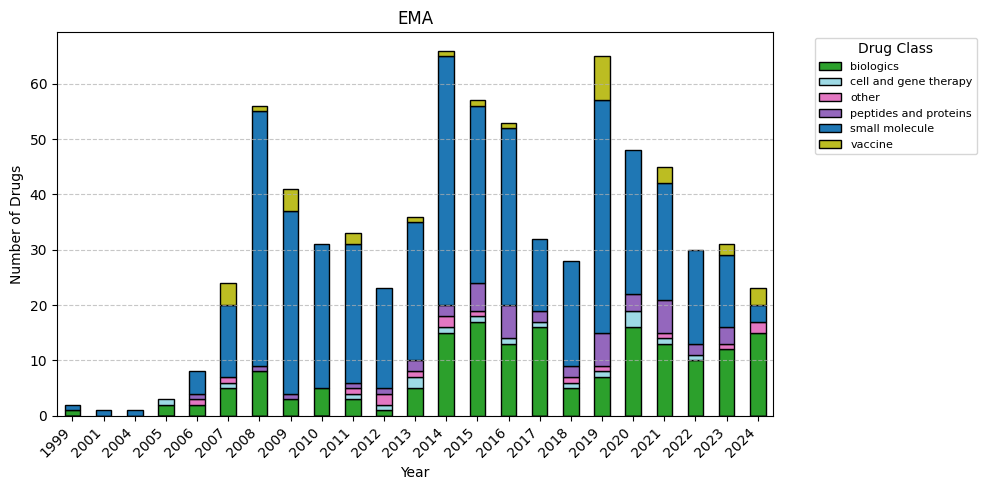

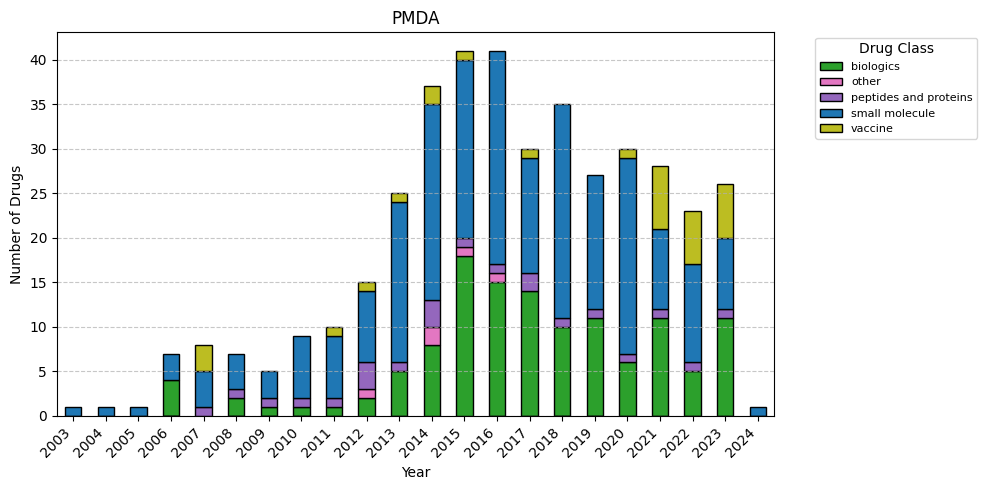

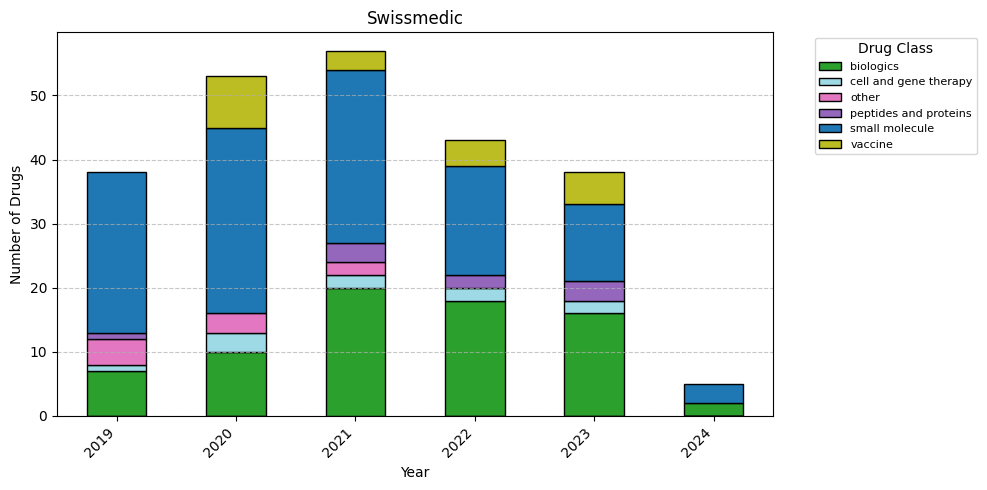

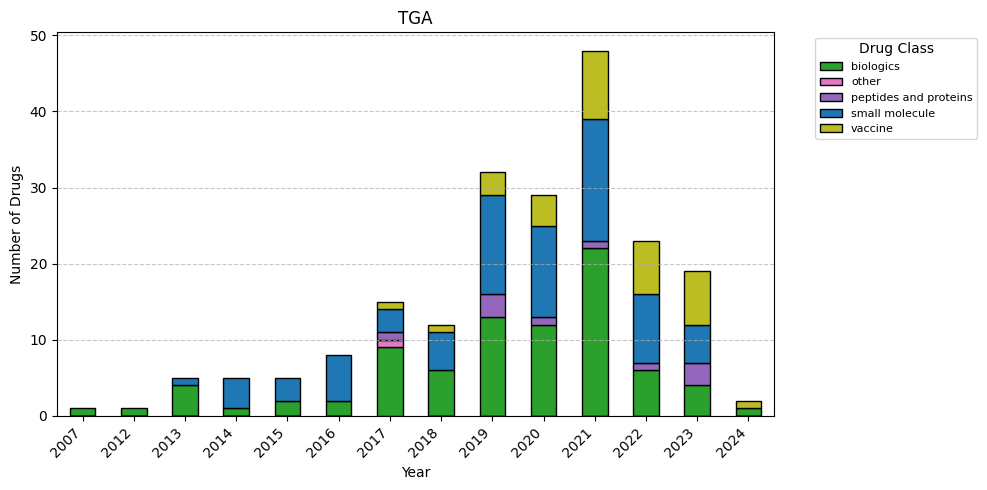

In [10]:

for k,v in DATASETS_1995.items():
    if 'Application_year' in v.columns:
        plot_drug_class_per_application_year_absolute(v, drug_class_colormap=drug_class_colormap, dataset_name=k)
    else:
        print(f"{k}: 'Application_year' column not found, skipping drug class plot.")


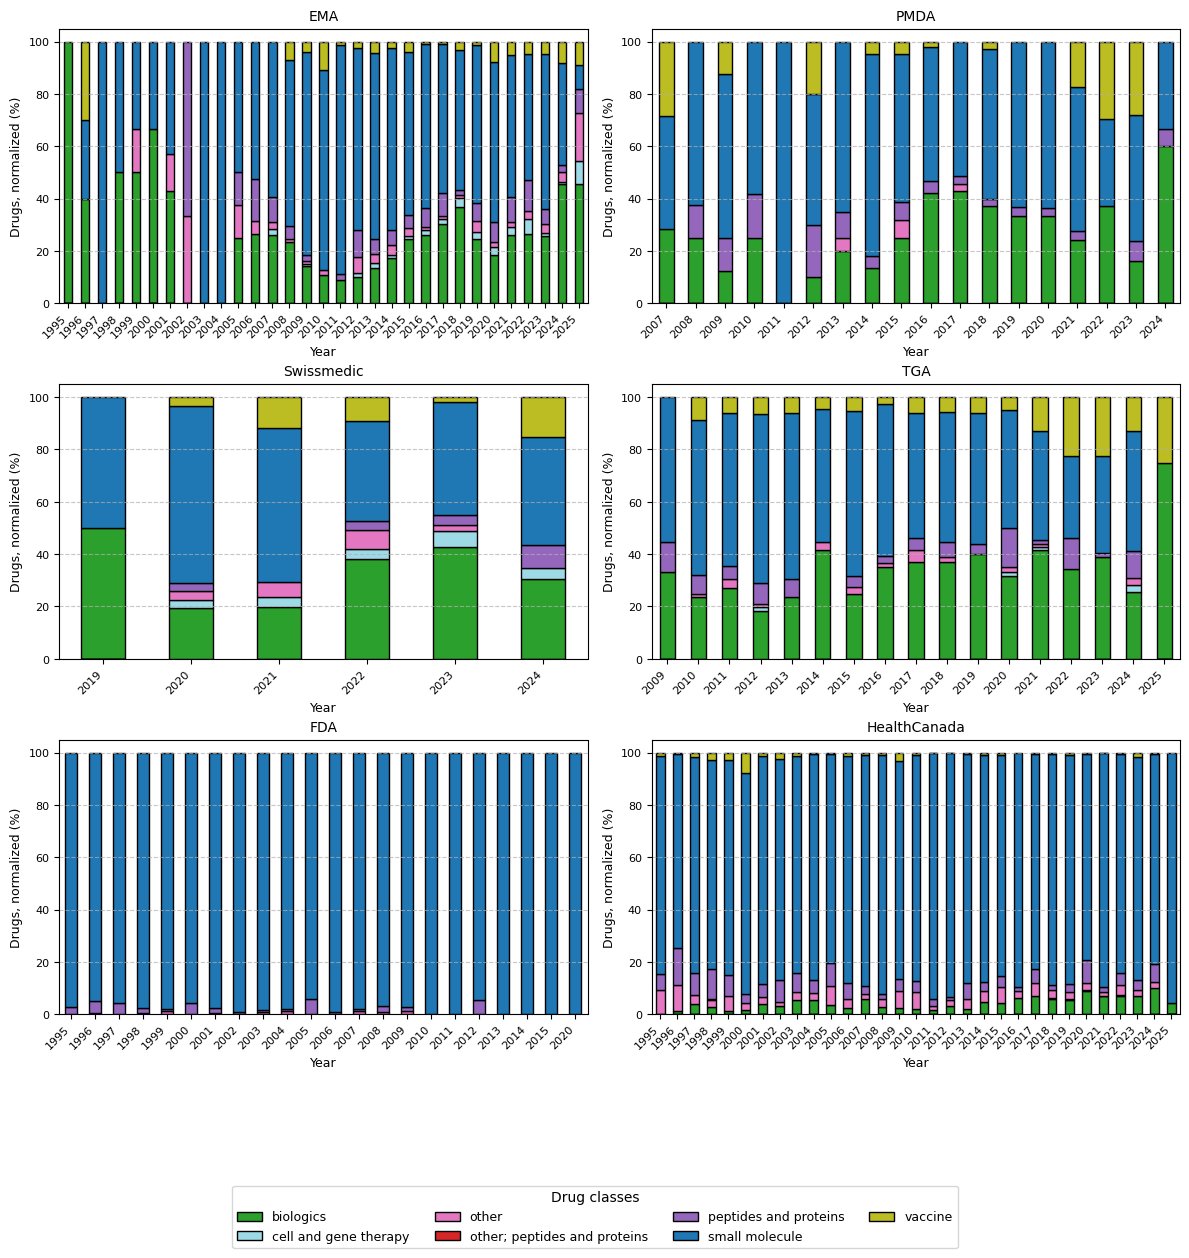

In [67]:
plot_drug_class_per_year_panel(
    DATASETS_1995, 
    date_col='Decision_year', 
    info_col="Drug_class",
    drug_class_colormap=drug_class_colormap, 
    nrows=3, 
    ncols=2,
    figsize_per_subplot=(6, 4)
)

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\863275249.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 1687, Final length after cleaning: 1687, Percentage kept: 100.00%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\863275249.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 408, Final length after cleaning: 408, Percentage kept: 100.00%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\863275249.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\863275249.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 234, Final length after cleaning: 234, Percentage kept: 100.00%
Original length: 1042, Final length after cleaning: 1042, Percentage kept: 100.00%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\863275249.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 3033, Final length after cleaning: 3033, Percentage kept: 100.00%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\863275249.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 10286, Final length after cleaning: 10286, Percentage kept: 100.00%


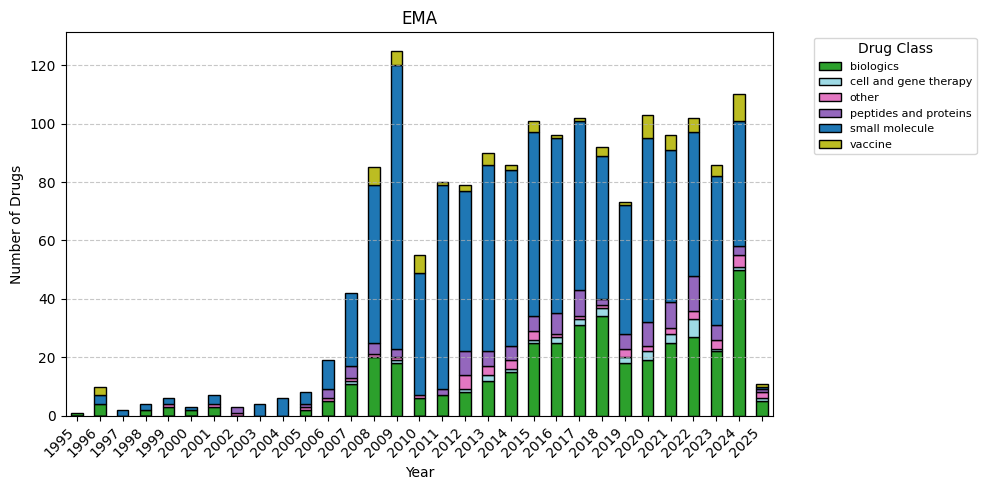

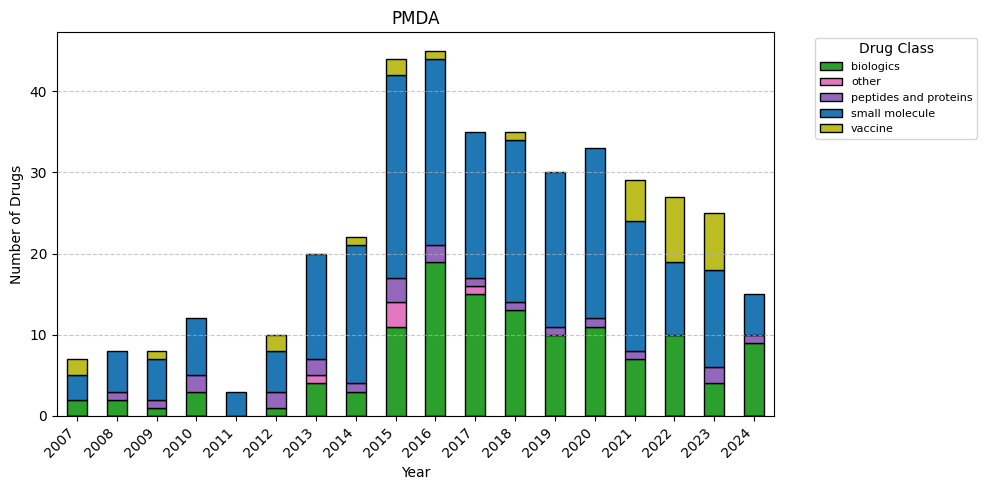

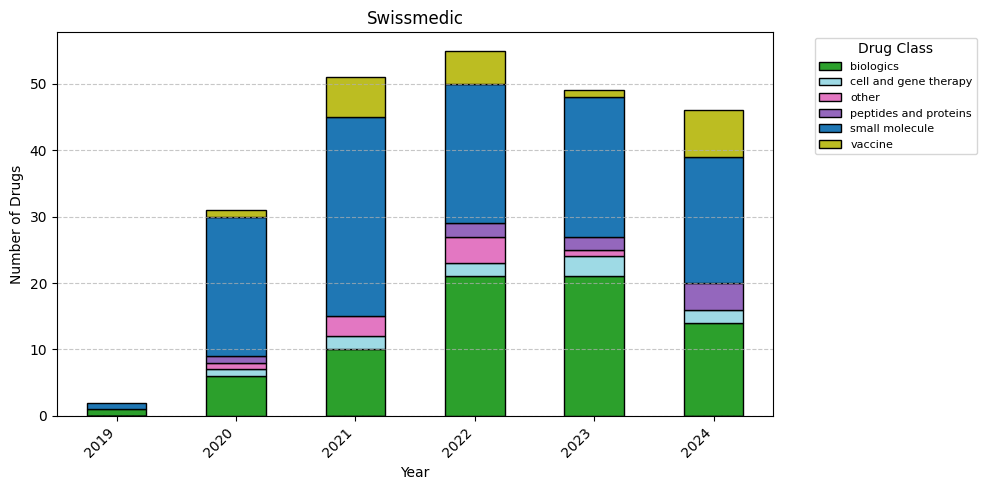

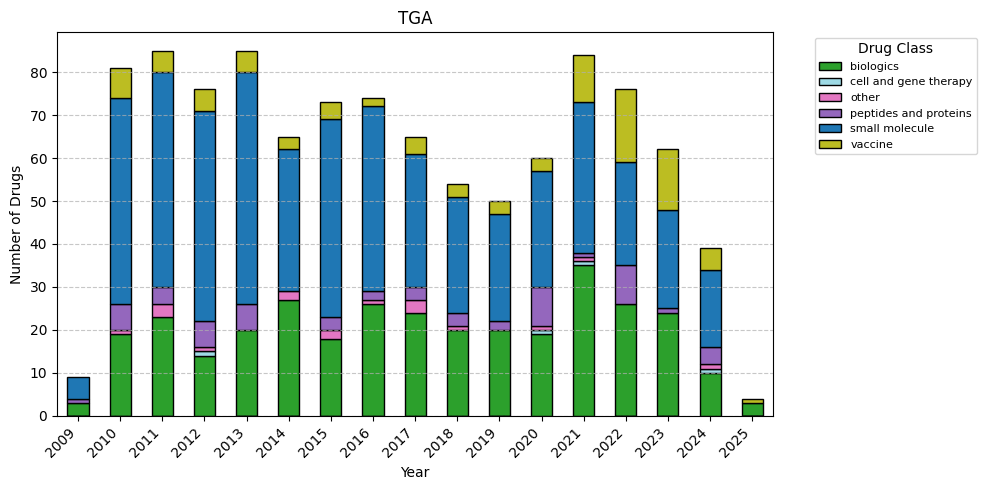

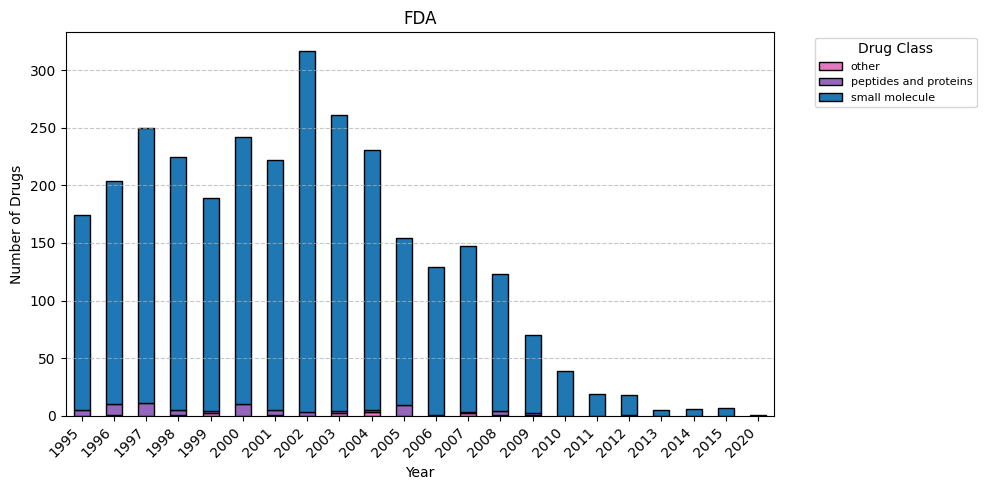

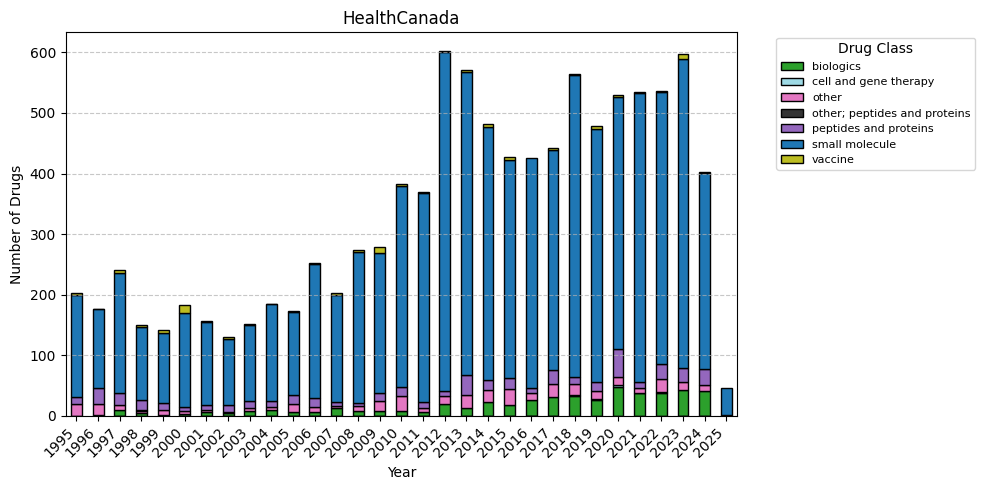

In [324]:
for k,v in DATASETS_1995.items():
    if 'Decision_year' in v.columns:
        plot_drug_class_per_decision_year_absolute(v, drug_class_colormap=drug_class_colormap, dataset_name=k)
    else:
        print(f"{k}: 'Decision_year' column not found, skipping drug class plot.")

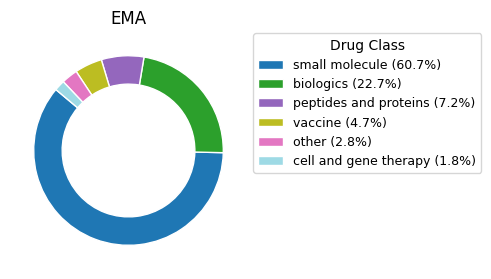

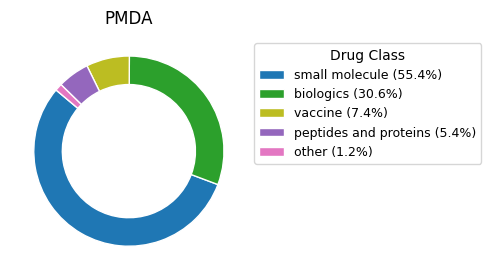

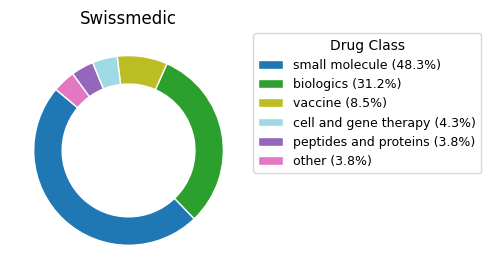

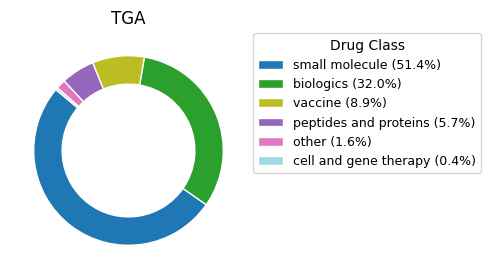

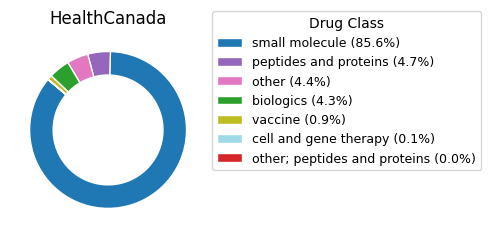

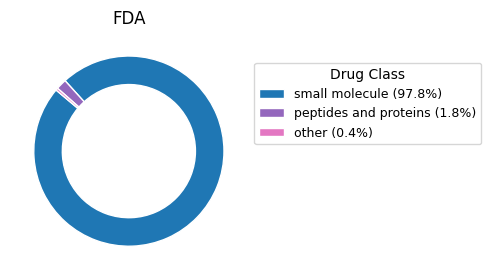

In [325]:
for k,v in DATASETS.items():
    if 'Drug_class' in v.columns:
        plot_drug_class_distribution_pie(v, drug_class_colormap, dataset_name=k)
    else:
        print(f"{k}: 'Drug_class' column not found, skipping drug class distribution pie chart.")

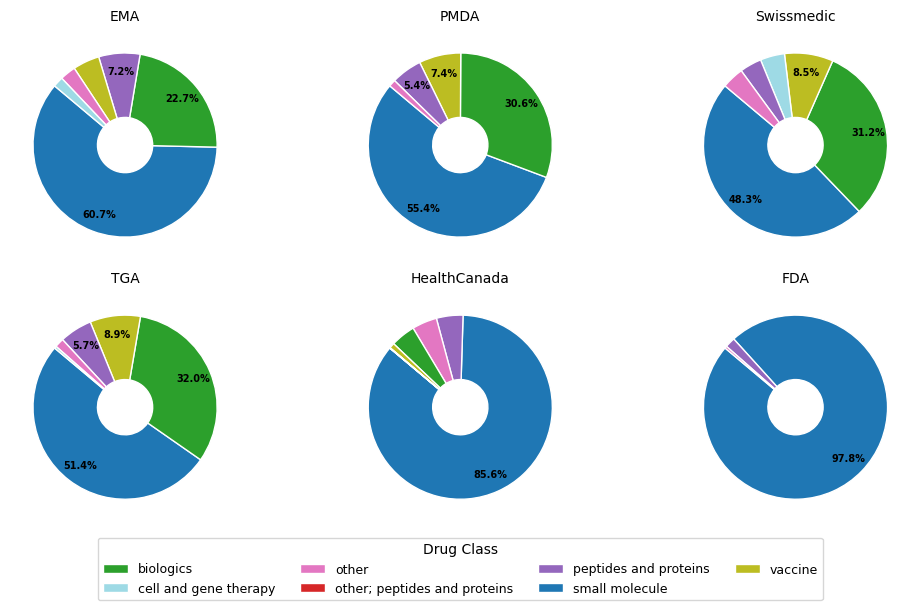

In [58]:
# Panel plot for drug class distribution (pie charts)
plot_drug_class_distribution_pie_panel(
    DATASETS, 
    drug_class_colormap=drug_class_colormap, 
    nrows=2, 
    ncols=3,
    figsize_per_subplot=(3.5, 3)
)

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\863275249.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 1687, Final length after cleaning: 1687, Percentage kept: 100.00%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\863275249.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 408, Final length after cleaning: 408, Percentage kept: 100.00%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\863275249.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


...

Original length: 1042, Final length after cleaning: 1042, Percentage kept: 100.00%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\863275249.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 3033, Final length after cleaning: 3033, Percentage kept: 100.00%


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\863275249.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 10286, Final length after cleaning: 10286, Percentage kept: 100.00%


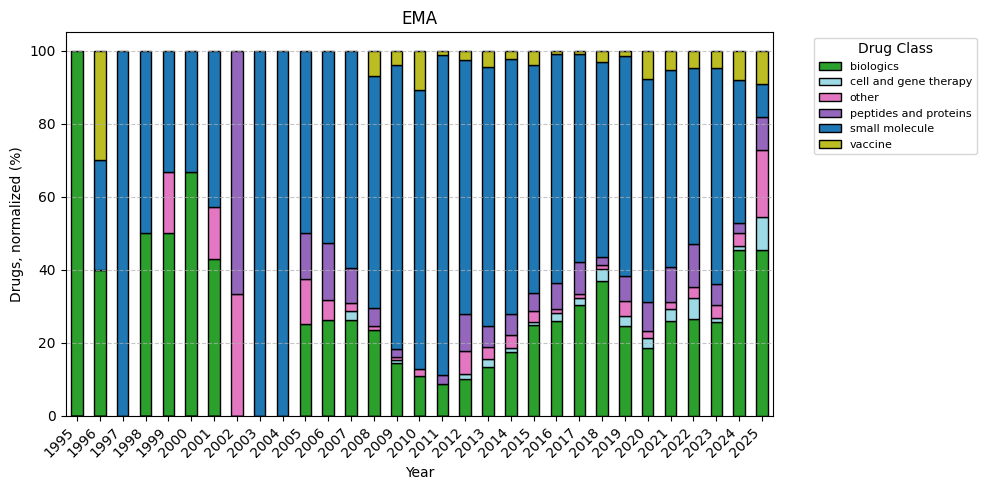

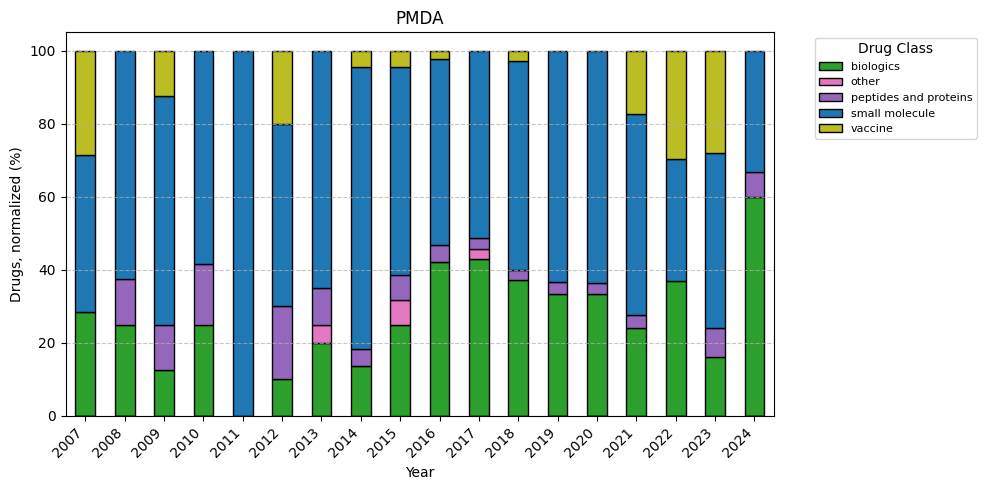

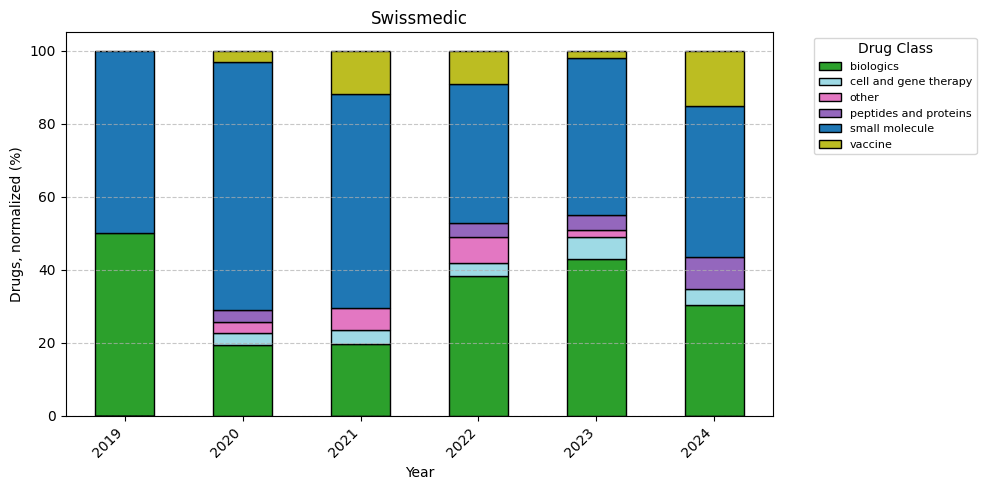

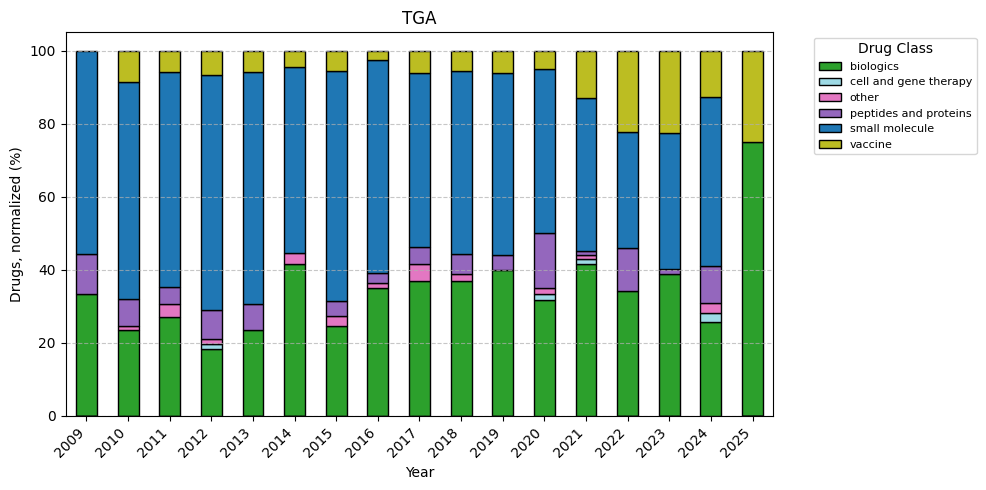

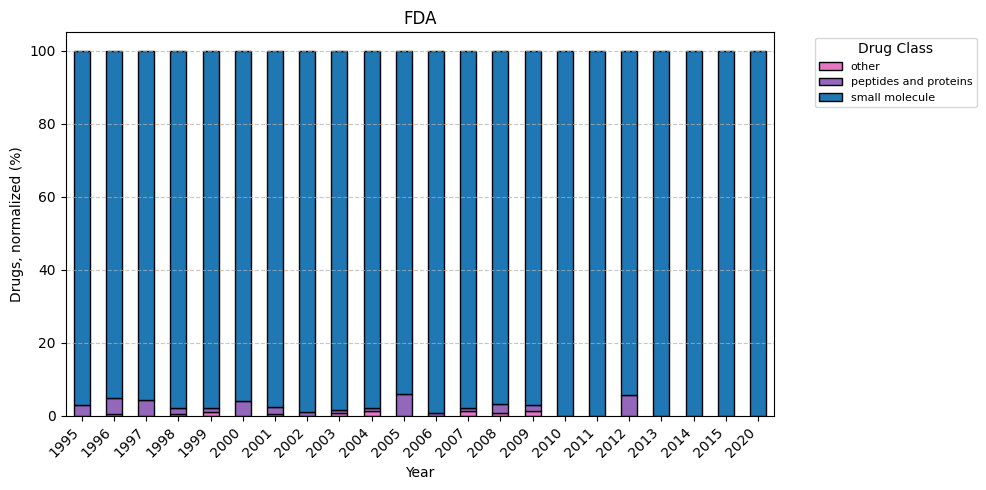

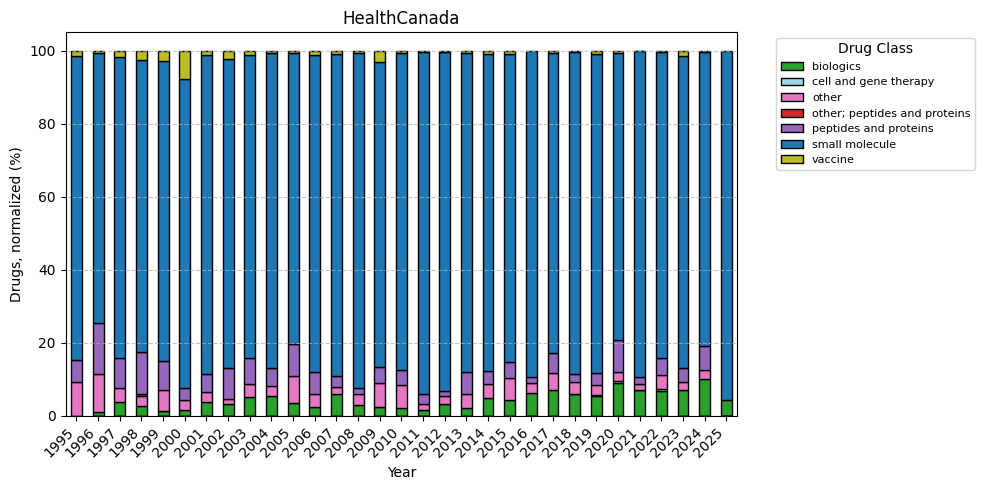

In [326]:
for k,v in DATASETS_1995.items():
    if 'Decision_year' in v.columns:
        plot_drug_class_per_year(v, date_col='Decision_year', drug_class_colormap=drug_class_colormap, dataset_name=k)
    else:
        print(f"{k}: 'Decision_year' column not found, skipping disease class per decision year plot.")

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\863275249.py:340: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\863275249.py:340: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\863275249.py:340: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\863275249.py:340: UserWarning: Parsing dates in %d.%m.%Y forma

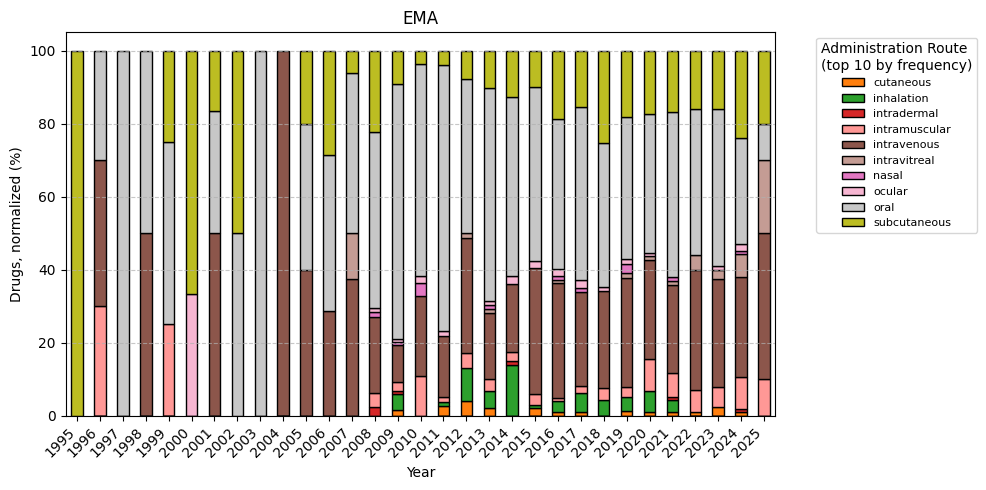

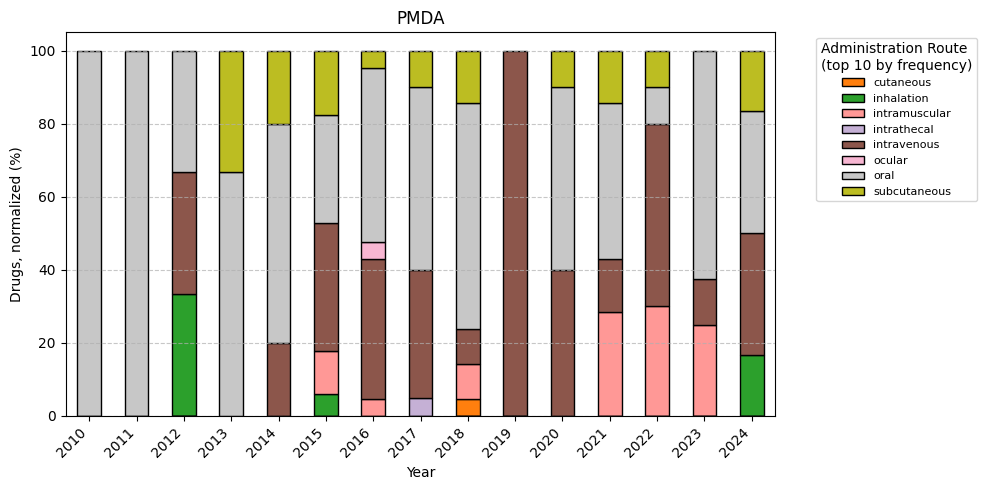

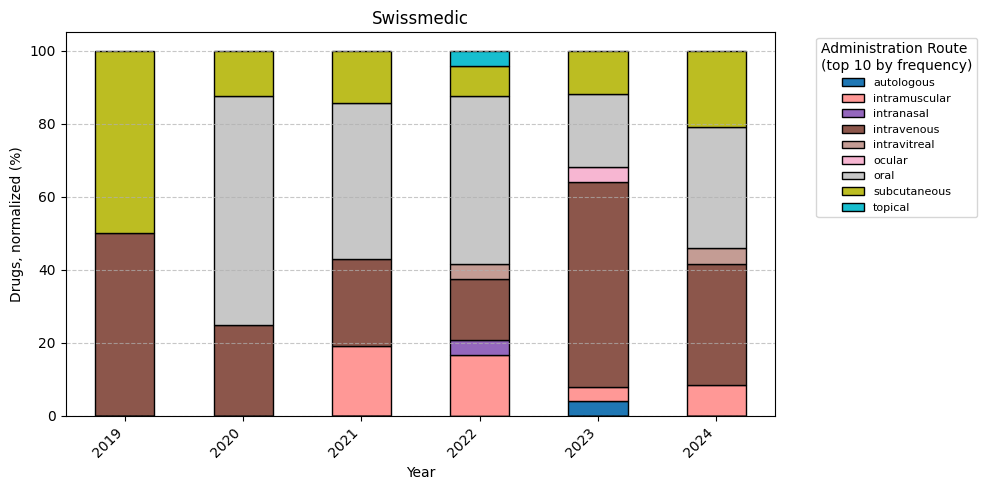

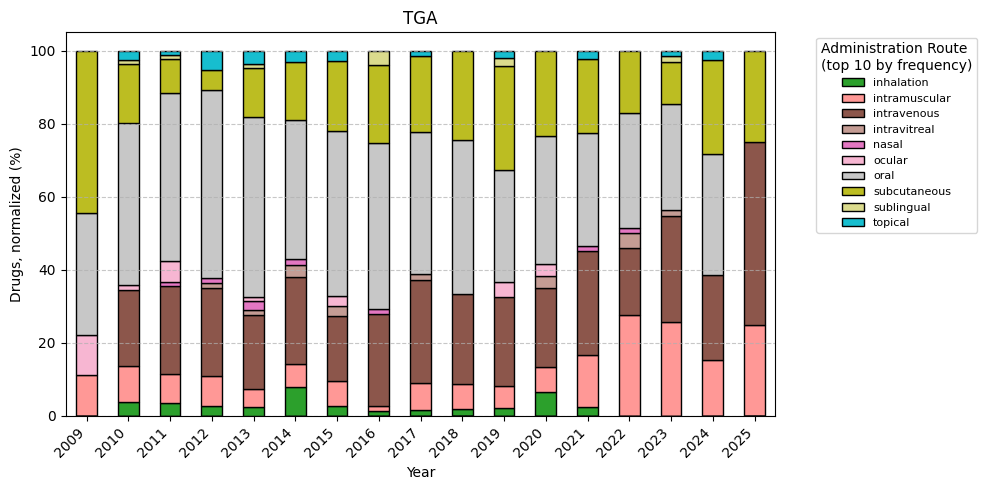

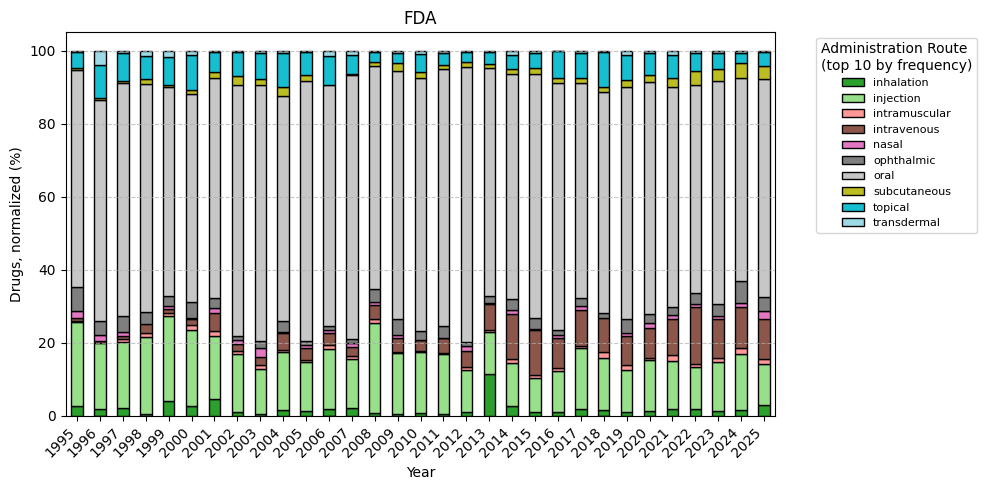

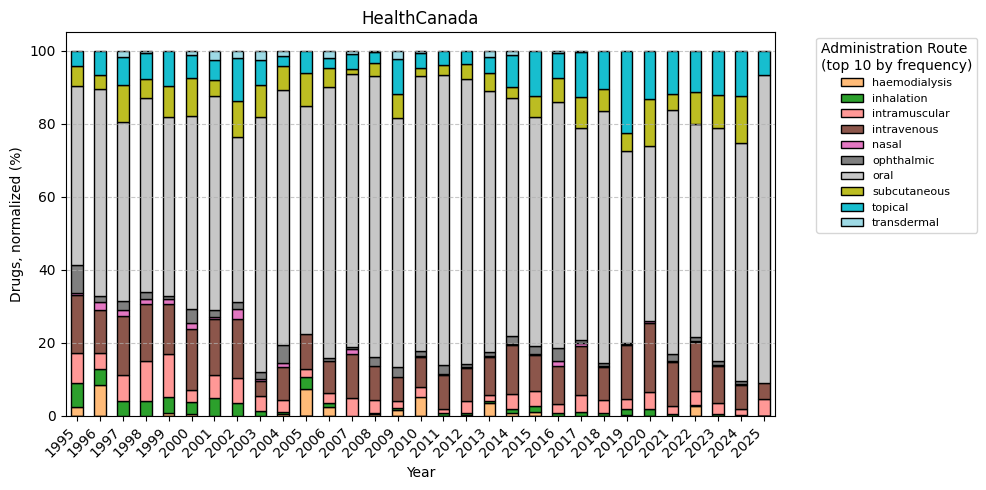

In [ ]:
plot_drug_class_per_year_panel(
    DATASETS_1995, 
    date_col='Decision_year', 
    info_col="Administration_route",
    drug_class_colormap=admin_route_colormap,  # Changed from admin_route_cmap to admin_route_colormap
    nrows=3, 
    ncols=2,
    figsize_per_subplot=(6, 4)
)

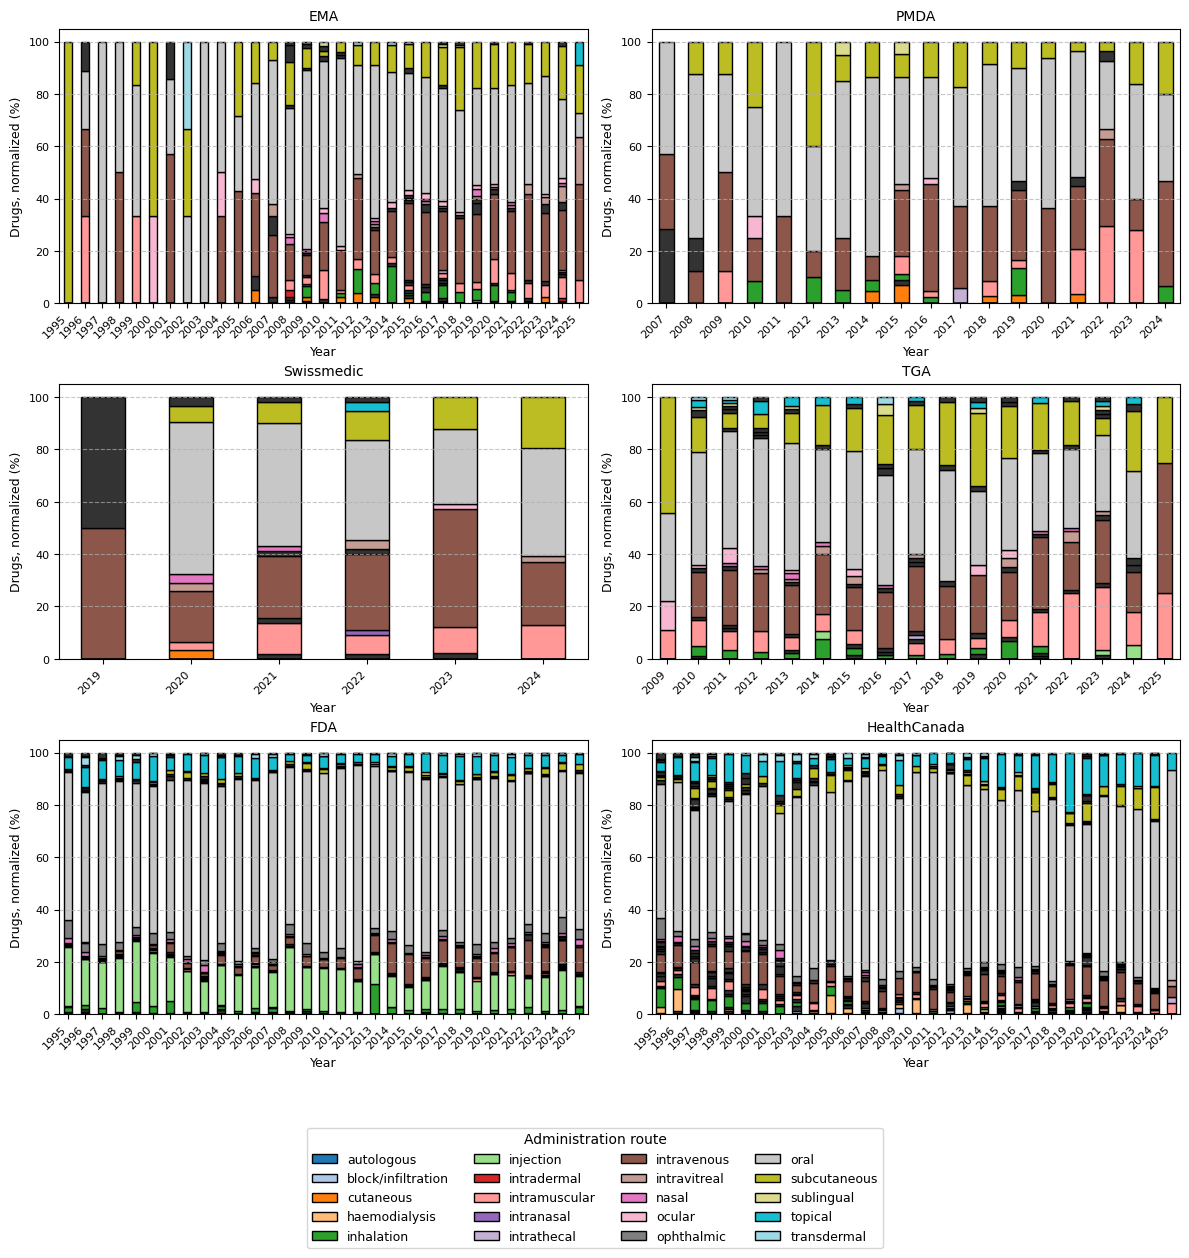

In [70]:
plot_drug_class_per_year_panel(
    DATASETS_1995, 
    date_col='Decision_year', 
    info_col="Administration_route",
    drug_class_colormap=admin_route_colormap, 
    nrows=3, 
    ncols=2,
    figsize_per_subplot=(6, 4)
)

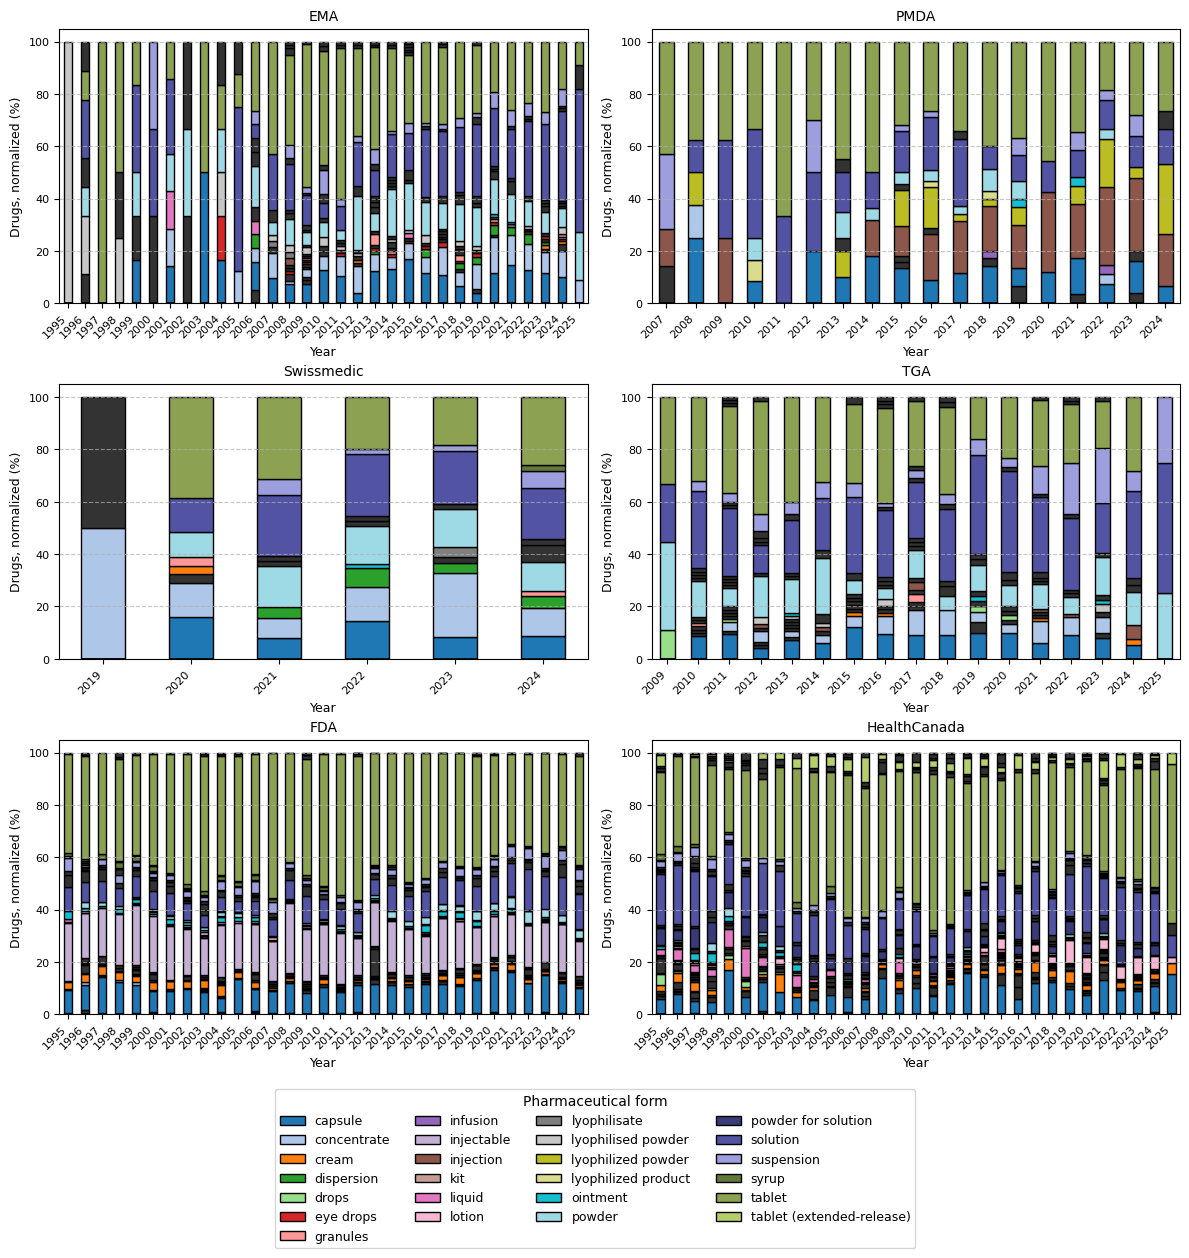

In [66]:
plot_drug_class_per_year_panel(
    DATASETS_1995, 
    date_col='Decision_year', 
    info_col="Pharmaceutical_form",
    drug_class_colormap=pharma_form_colormap, 
    nrows=3, 
    ncols=2,
    figsize_per_subplot=(6, 4)
)

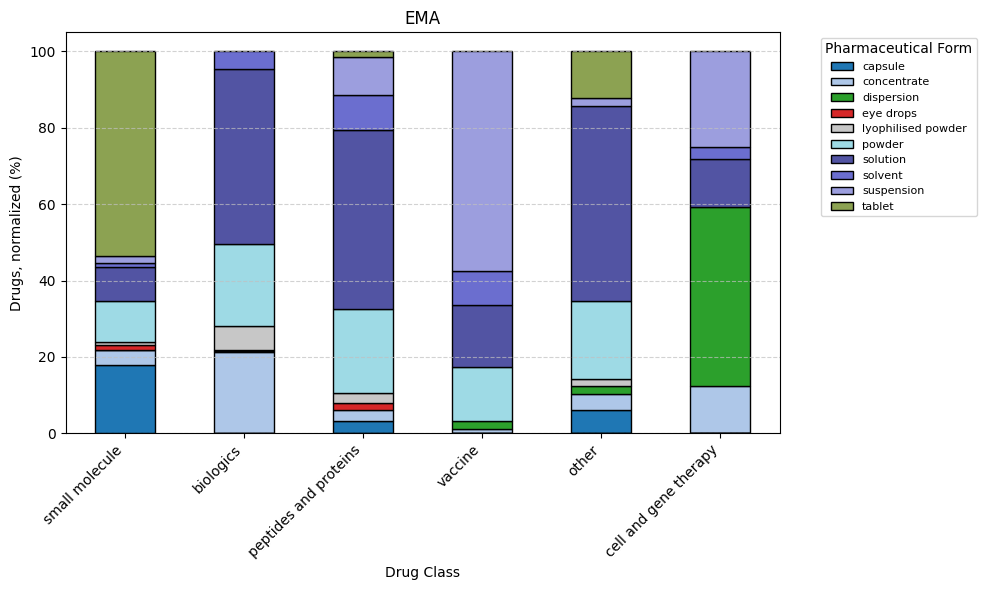

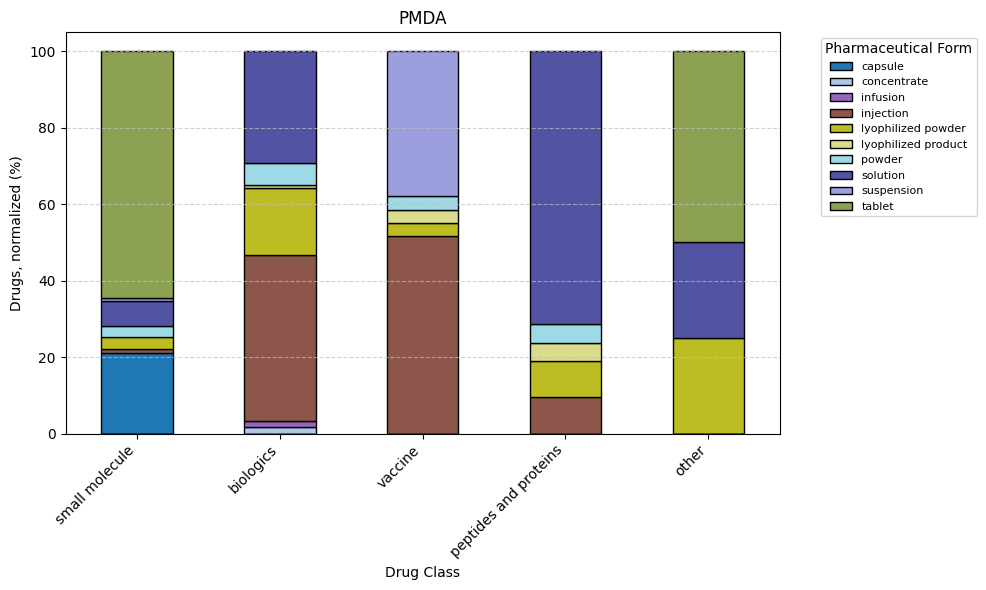

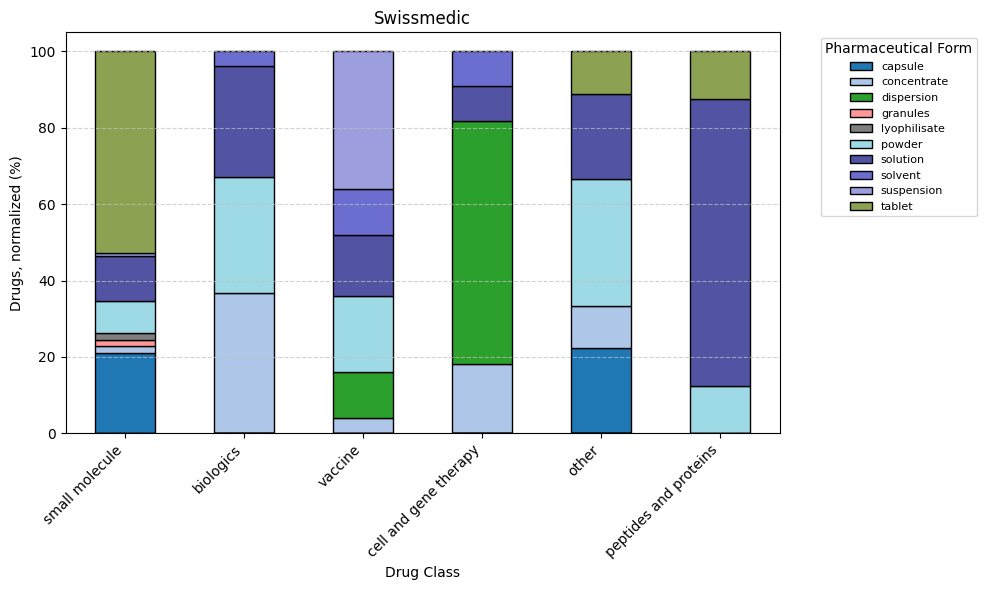

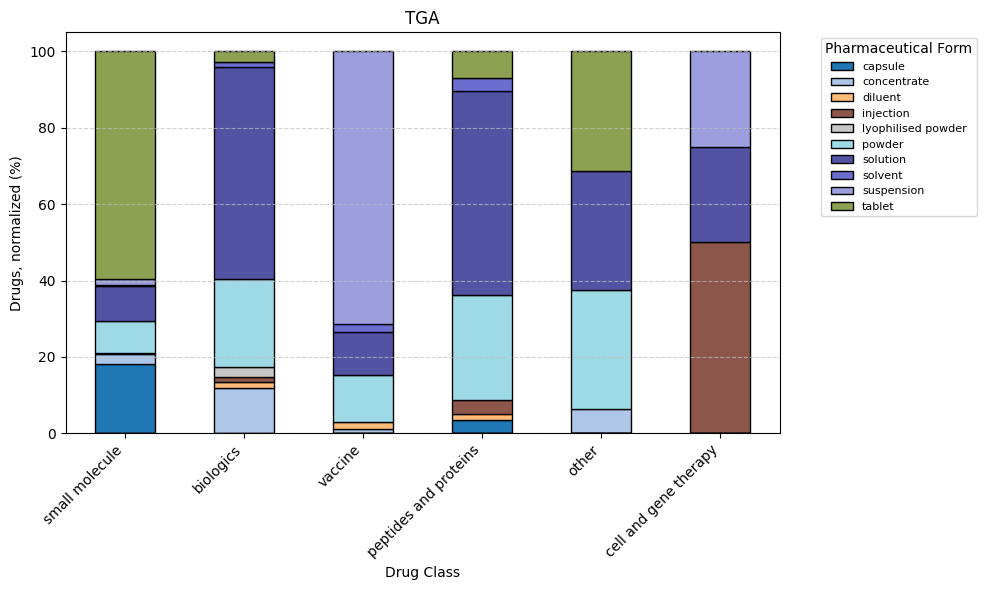

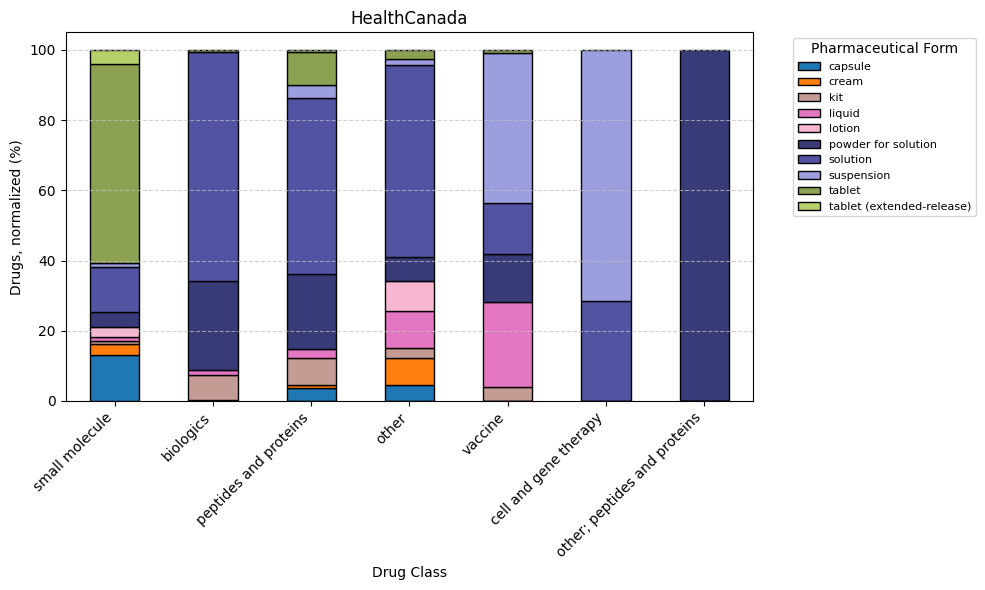

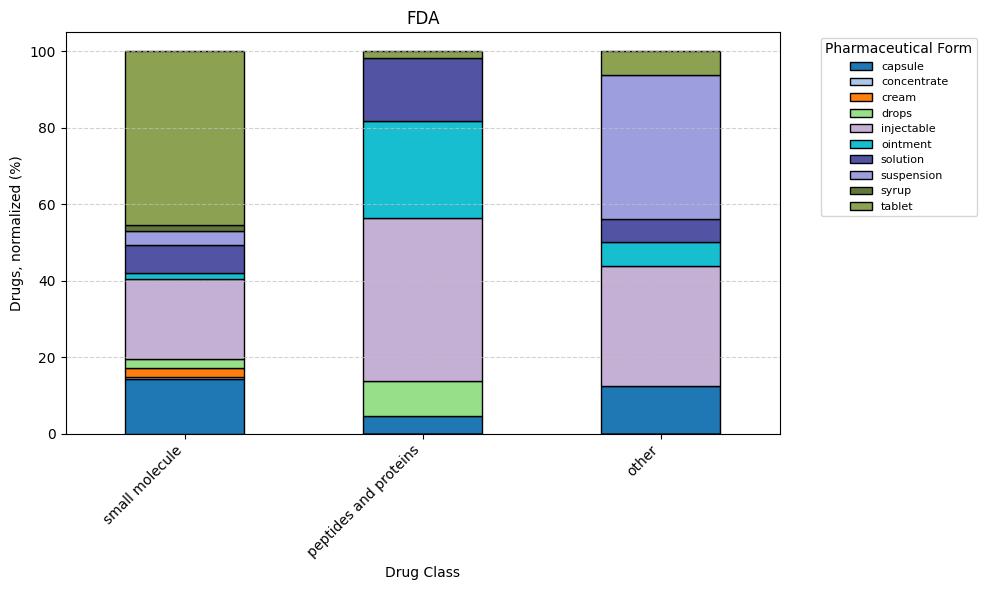

In [329]:
for k,v in DATASETS.items():
    if 'Pharmaceutical_form' in v.columns:
        plot_drug_class_by_pharmaceutical_form(v, pharma_form_colormap=pharma_form_colormap, dataset_name=k)
    else:
        print(f"{k}: 'Pharmaceutical_form' column not found, skipping drug class by pharmaceutical form plot.")

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\863275249.py:446: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\863275249.py:446: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\863275249.py:446: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\863275249.py:446: UserWarning: Parsing dates in %d.%m.%Y forma

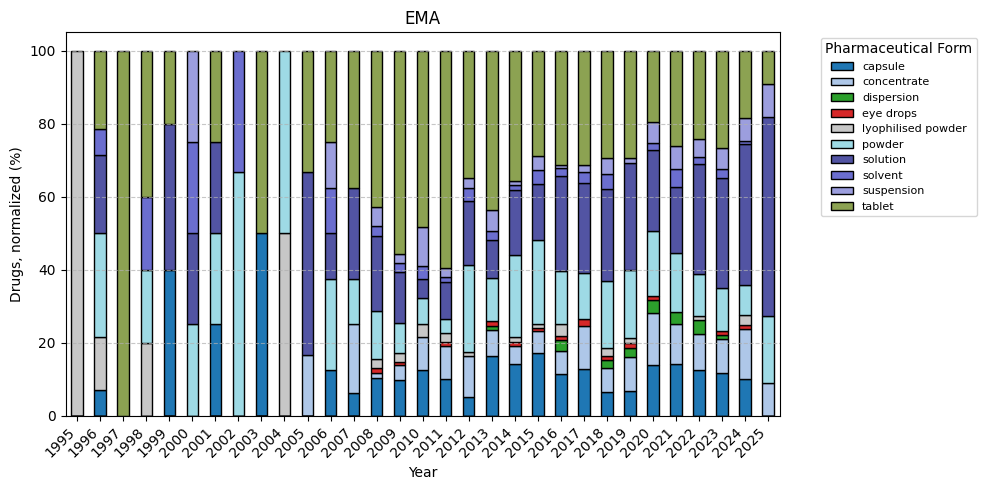

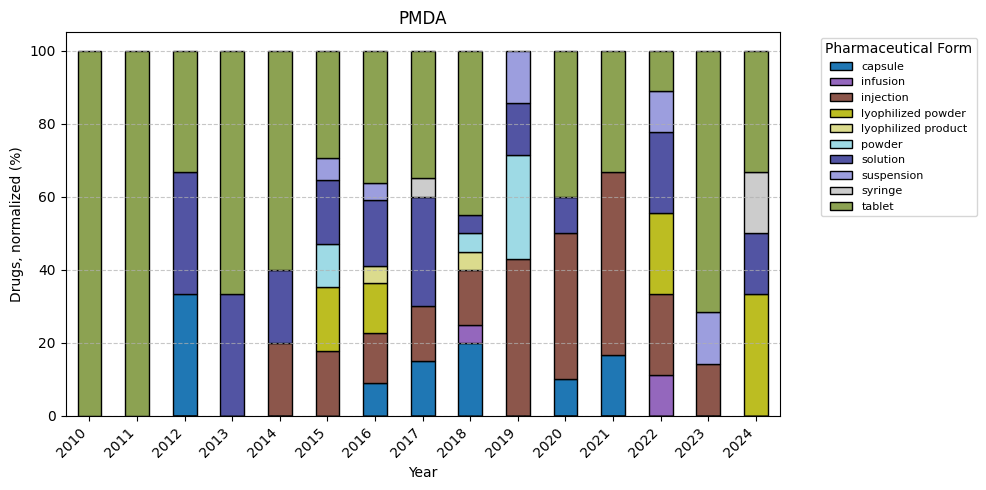

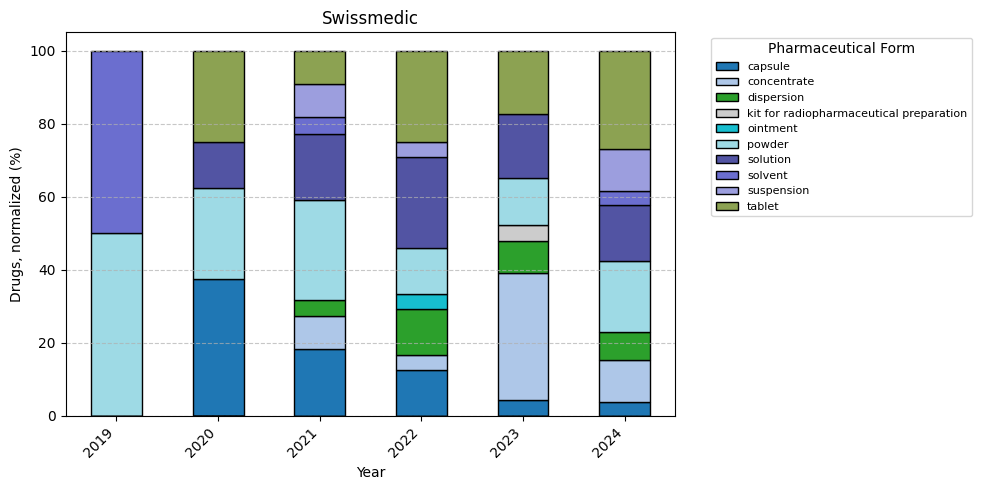

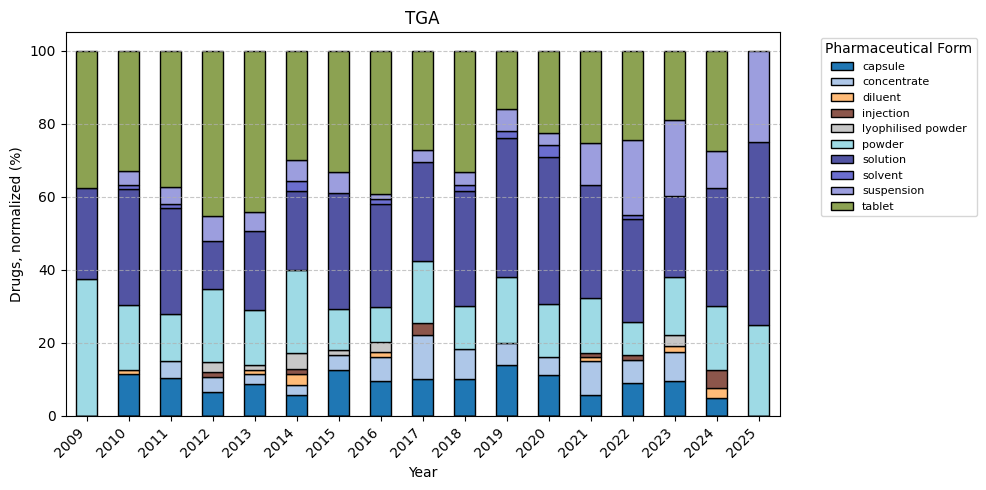

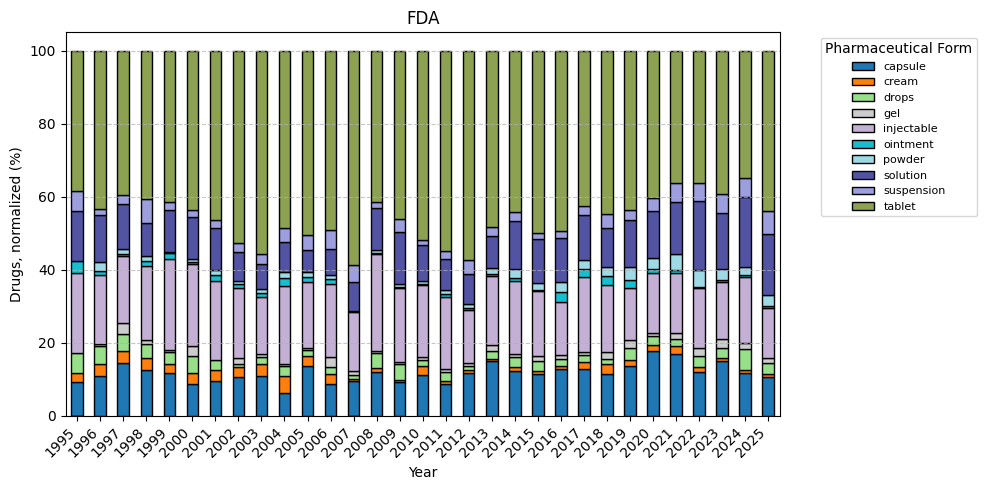

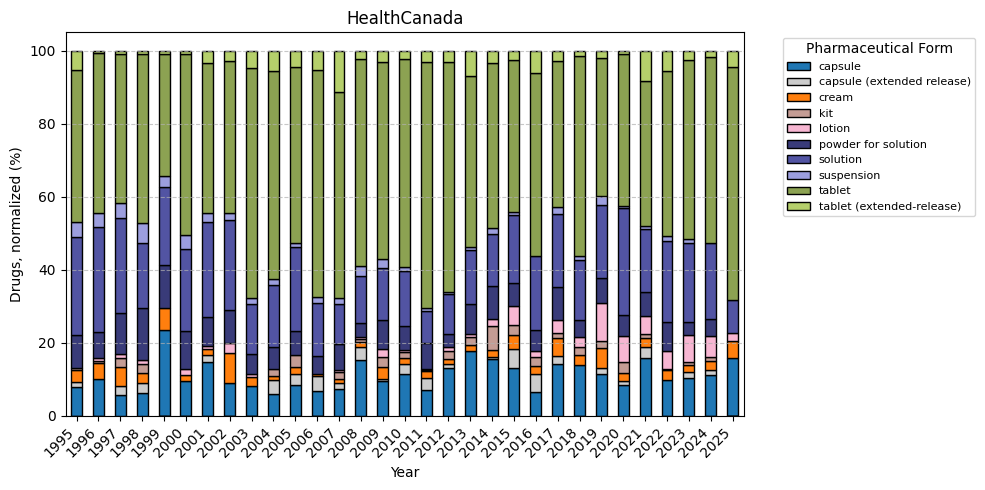

In [330]:
for k,v in DATASETS_1995.items():
    if "Decision_date" in v.columns:
        plot_pharmaceutical_form_per_year(v, agency_name=k, date_col='Decision_date', pharma_form_colormap=pharma_form_colormap, dataset_name=k)
    else:
        print(f"{k}: 'Decision_date' column not found, skipping pharmaceutical form per year plot.")

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\863275249.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 1687, Final length after cleaning: 1687, Percentage kept: 100.00%

Top 2 Disease Classes (absolute Häufigkeit):
neoplasms: 479
diseases of the blood and blood-forming organs: 288


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\863275249.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 408, Final length after cleaning: 408, Percentage kept: 100.00%

Top 2 Disease Classes (absolute Häufigkeit):
neoplasms: 129
infectious and parasitic diseases: 79


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\863275249.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 234, Final length after cleaning: 234, Percentage kept: 100.00%

Top 2 Disease Classes (absolute Häufigkeit):
neoplasms: 73
diseases of the blood and blood-forming organs: 50


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\863275249.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 1042, Final length after cleaning: 1042, Percentage kept: 100.00%

Top 2 Disease Classes (absolute Häufigkeit):
neoplasms: 278
infectious and parasitic diseases: 182


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\863275249.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  dt_years = pd.to_datetime(df[col_name], errors='coerce', infer_datetime_format=True).dt.year


Original length: 3088, Final length after cleaning: 3088, Percentage kept: 100.00%

Top 2 Disease Classes (absolute Häufigkeit):
diseases of the nervous system: 540
infectious and parasitic diseases: 507
HealthCanada: 'Decision_year' or 'Disease_class(es)' column not found, skipping disease class per decision year absolute plot.
HealthCanada: 'Decision_year' or 'Disease_class(es)' column not found, skipping disease class per decision year absolute plot.


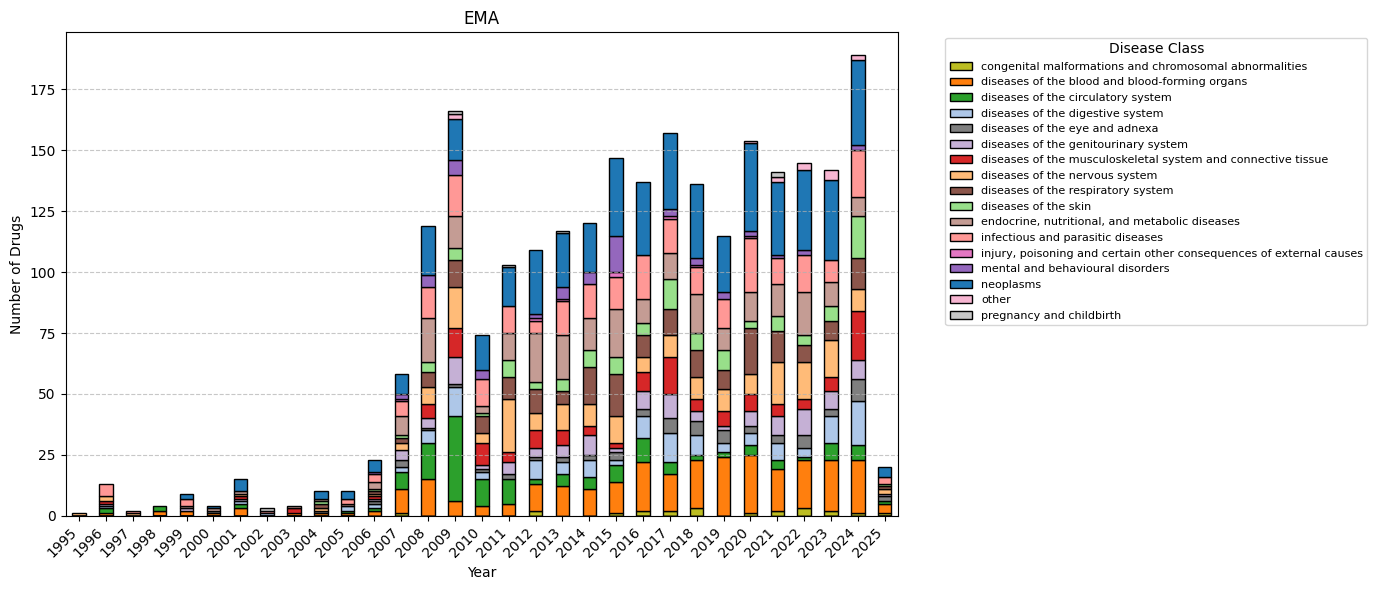

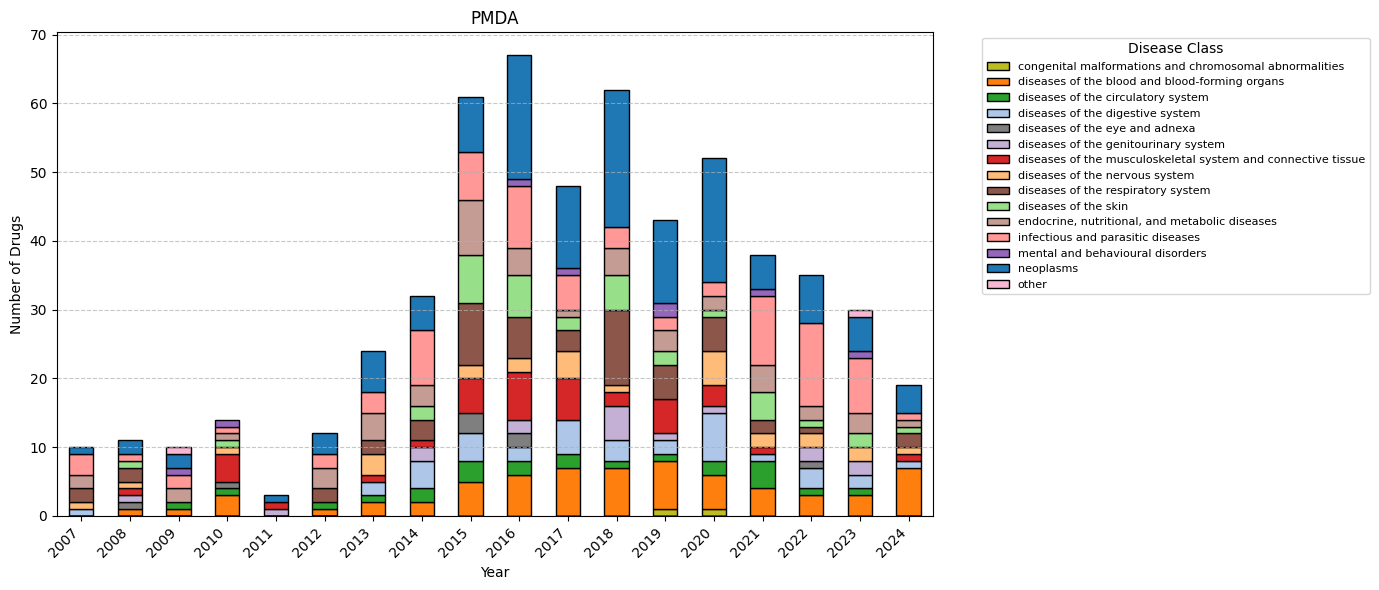

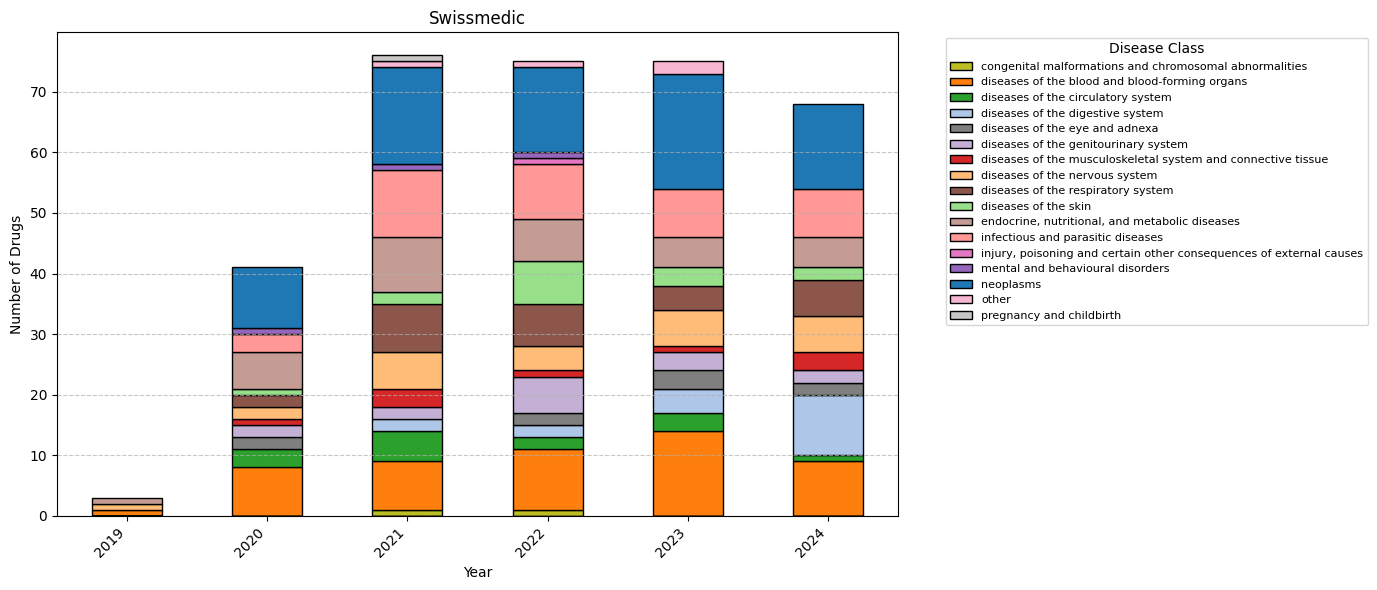

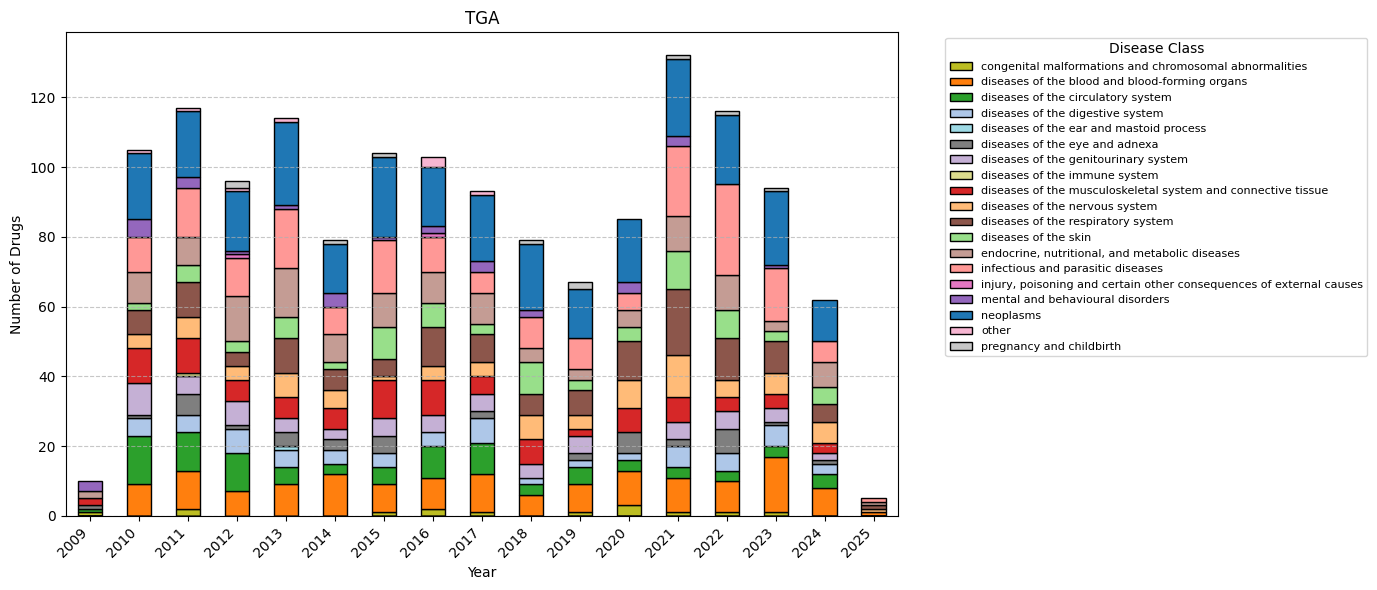

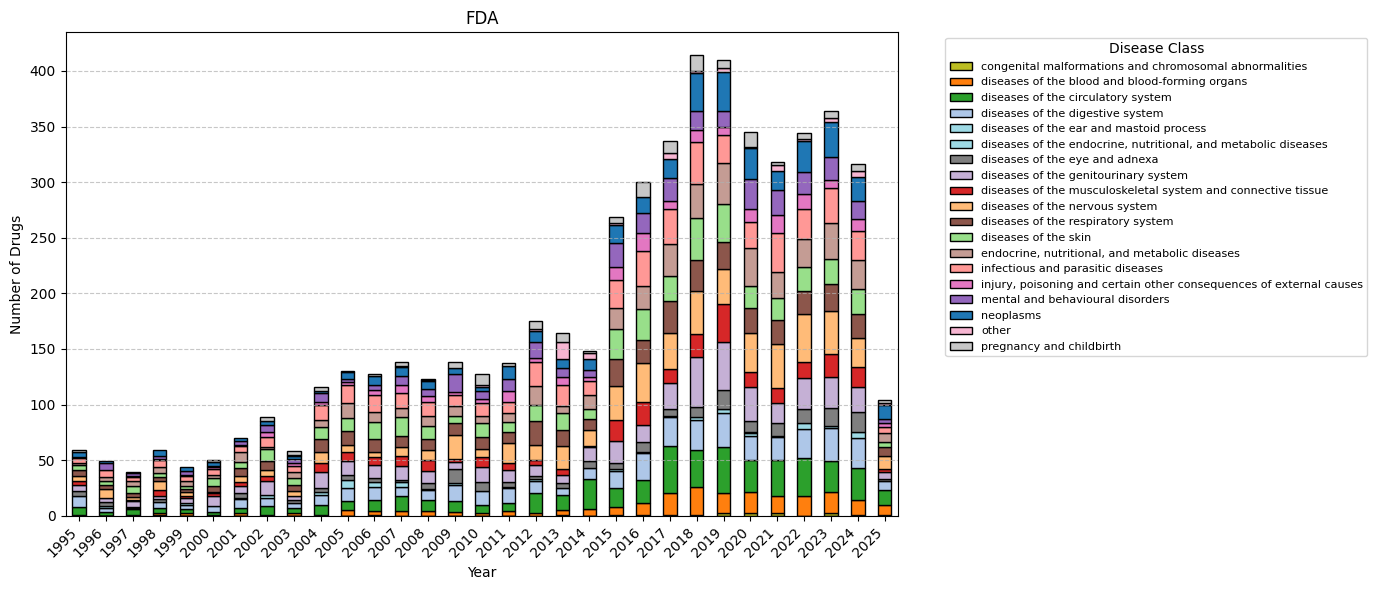

In [331]:
for k,v in DATASETS_1995.items():
    if 'Decision_year' in v.columns and 'Disease_class(es)' in v.columns:
        plot_disease_class_per_decision_year_absolute(v, year_col='Decision_year', disease_class_colormap=disease_class_colormap, dataset_name=k)
    else:
        print(f"{k}: 'Decision_year' or 'Disease_class(es)' column not found, skipping disease class per decision year absolute plot.")

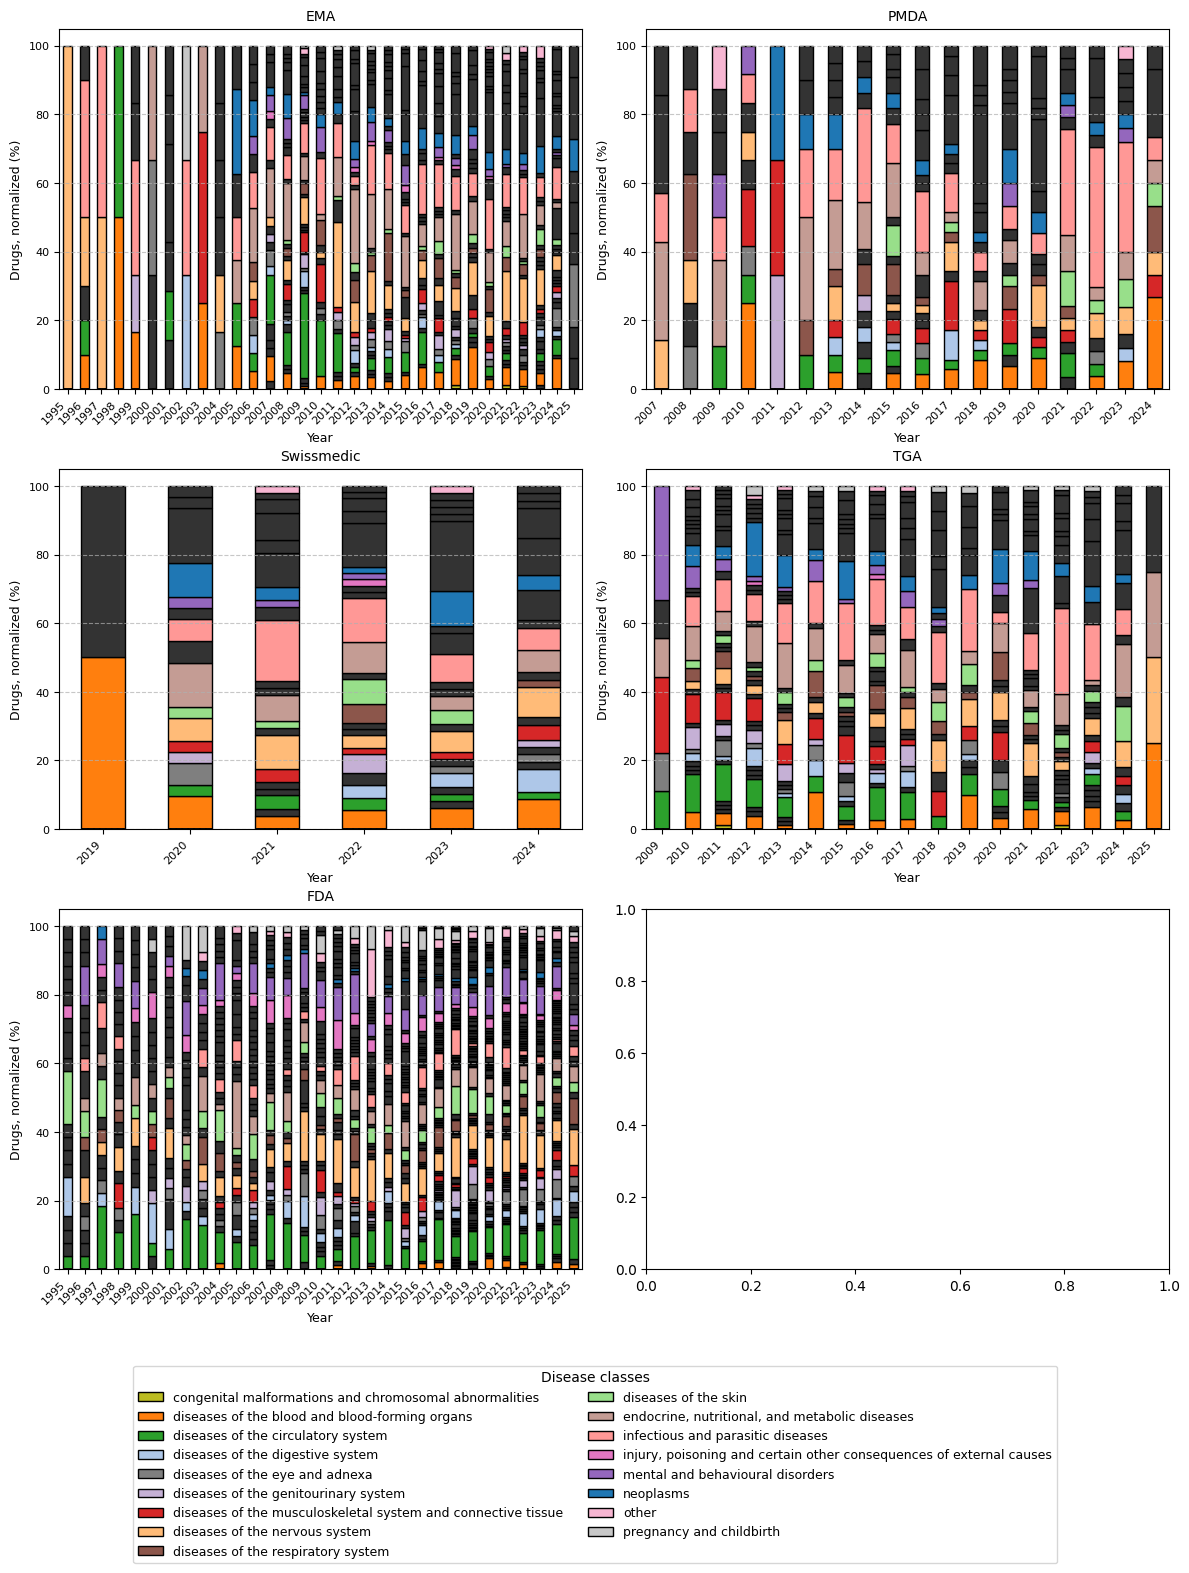

In [77]:
plot_drug_class_per_year_panel(
    DATASETS_1995, 
    date_col='Decision_year', 
    info_col="Disease_class(es)",
    drug_class_colormap=disease_class_colormap, 
    nrows=3, 
    ncols=2,
    figsize_per_subplot=(6, 5)
)

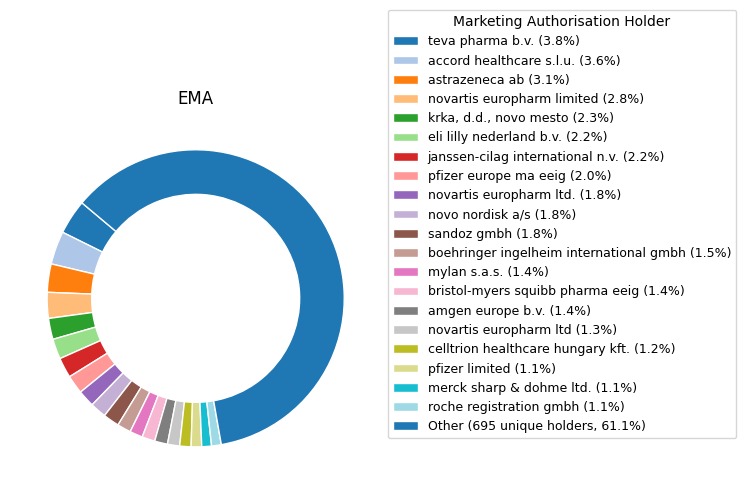

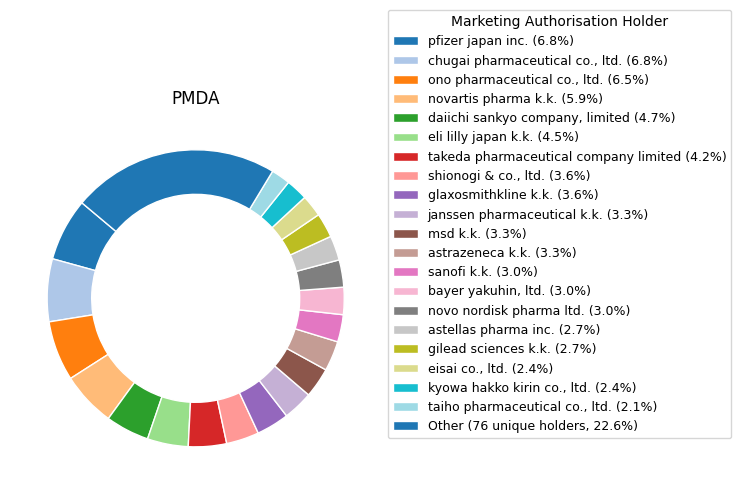

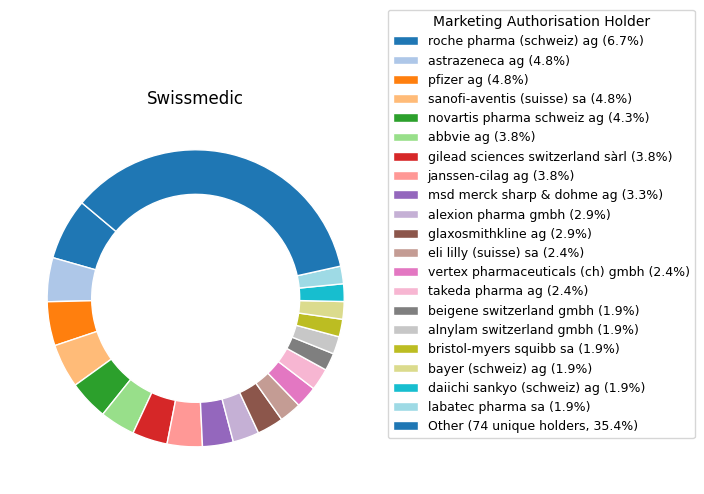

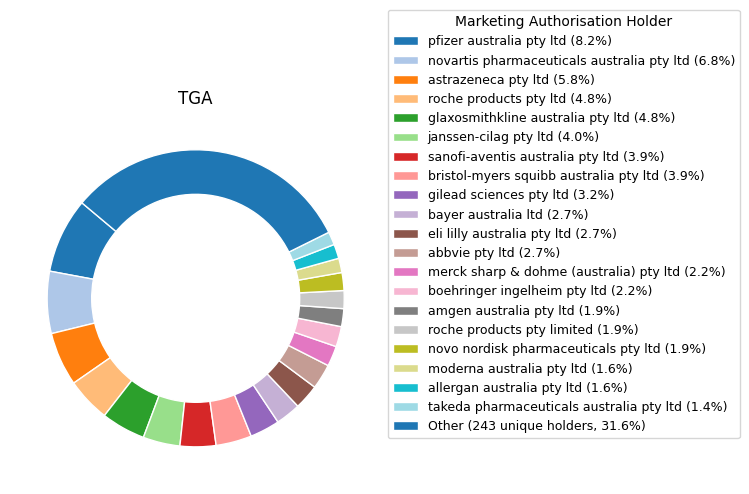

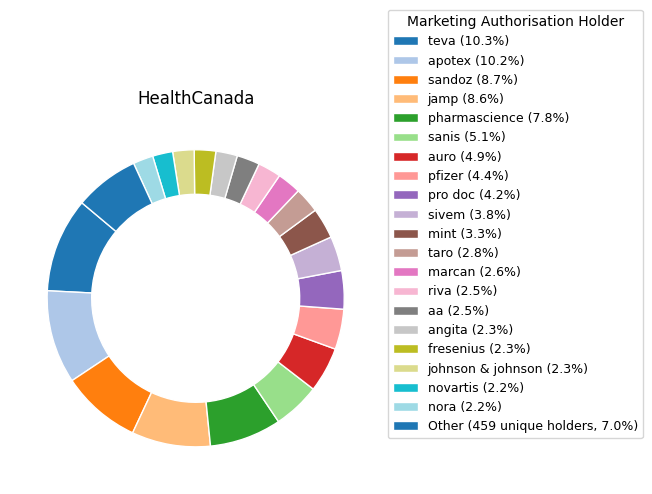

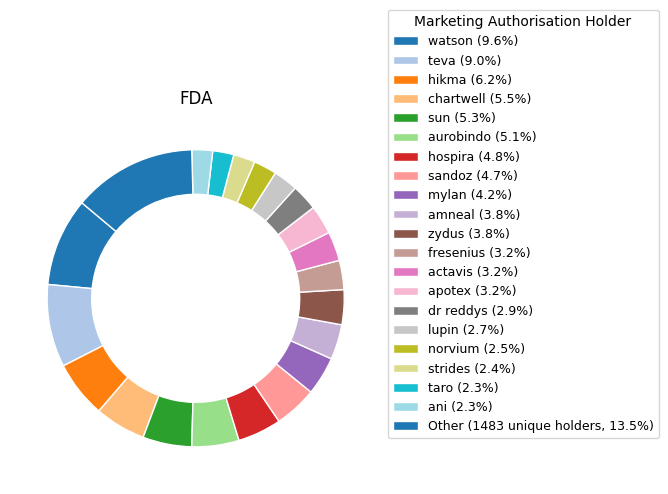

In [332]:
for k,v in DATASETS.items():
    if 'Marketing_authorisation_holder_extracted' in v.columns:
        plot_marketing_holder_distribution_pie(v, data_col='Marketing_authorisation_holder_extracted', dataset_name=k)
    else:
        if 'Marketing_authorisation_holder' in v.columns:
            plot_marketing_holder_distribution_pie(v, data_col='Marketing_authorisation_holder', dataset_name=k)
        else:
            print(f"{k}: 'Marketing_authorisation_holder' column not found, skipping marketing holder distribution pie chart.")
            continue

In [333]:
all_holders_combined = pd.concat(
    [EMA['Marketing_authorisation_holder'], 
     JAPAN['Marketing_authorisation_holder'], 
     SWISSMEDIC['Marketing_authorisation_holder']
     ])    
all_holders_combined = all_holders_combined.dropna().unique()

def sort_by_name(df, col_name):
    df = df.copy()
    df[col_name] = df[col_name].str.lower().str.strip()
    return df.sort_values(by=col_name)

EMA_sorted = sort_by_name(EMA, 'Marketing_authorisation_holder')
JAPAN_sorted = sort_by_name(JAPAN, 'Marketing_authorisation_holder')
SWISSMEDIC_sorted = sort_by_name(SWISSMEDIC, 'Marketing_authorisation_holder')

EMA_sorted_unique = EMA_sorted['Marketing_authorisation_holder'].unique()
JAPAN_sorted_unique = JAPAN_sorted['Marketing_authorisation_holder'].unique()
SWISSMEDIC_sorted_unique = SWISSMEDIC_sorted['Marketing_authorisation_holder'].unique()

with open(f"{SAVE_DIR}/EMA_marketing_authorisation_holders.txt", 'w', encoding="utf-8") as f:
    for holder in EMA_sorted_unique:
        f.write(f"{holder}\n")
with open(f"{SAVE_DIR}/JAPAN_marketing_authorisation_holders.txt", 'w') as f:
    for holder in JAPAN_sorted_unique:
        f.write(f"{holder}\n")
with open(f"{SAVE_DIR}/SWISSMEDIC_marketing_authorisation_holders.txt", 'w') as f:
    for holder in SWISSMEDIC_sorted_unique:
        f.write(f"{holder}\n")


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\863275249.py:632: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Nonclinical_abridged'] = valid['Nonclinical_abridged'].str.lower().str.strip()
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\863275249.py:632: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Nonclinical_abridged'] = valid['Nonclinical_abridged'].str.lower().str.strip()
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\863275249.py:632: SettingWithCopyWarning: 
A value is

HealthCanada: Missing required columns for review duration calculation.
FDA: Missing required columns for review duration calculation.


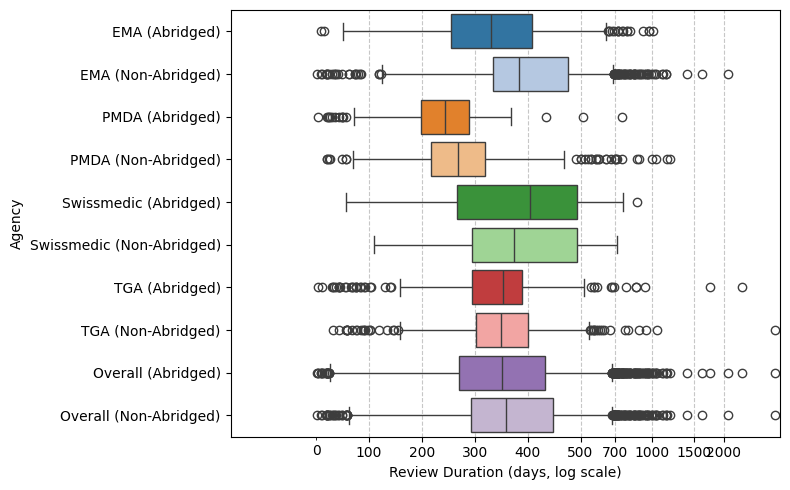

In [334]:
plot_review_duration_by_agency(
    agency_dfs=DATASETS,
    submission_col='Application_date',
    decision_col='Decision_date',
    dataset_name='combined'
)

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\863275249.py:736: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, y='Disease_class(es)', x='Review_duration_days',
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\863275249.py:736: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, y='Disease_class(es)', x='Review_duration_days',
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\863275249.py:736: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, y='Disease_class(es)', x='Review_duration_days',
C:\User

HealthCanada: 'Application_date' or 'Decision_date' column not found, skipping review duration by agency plot.
FDA: 'Application_date' or 'Decision_date' column not found, skipping review duration by agency plot.


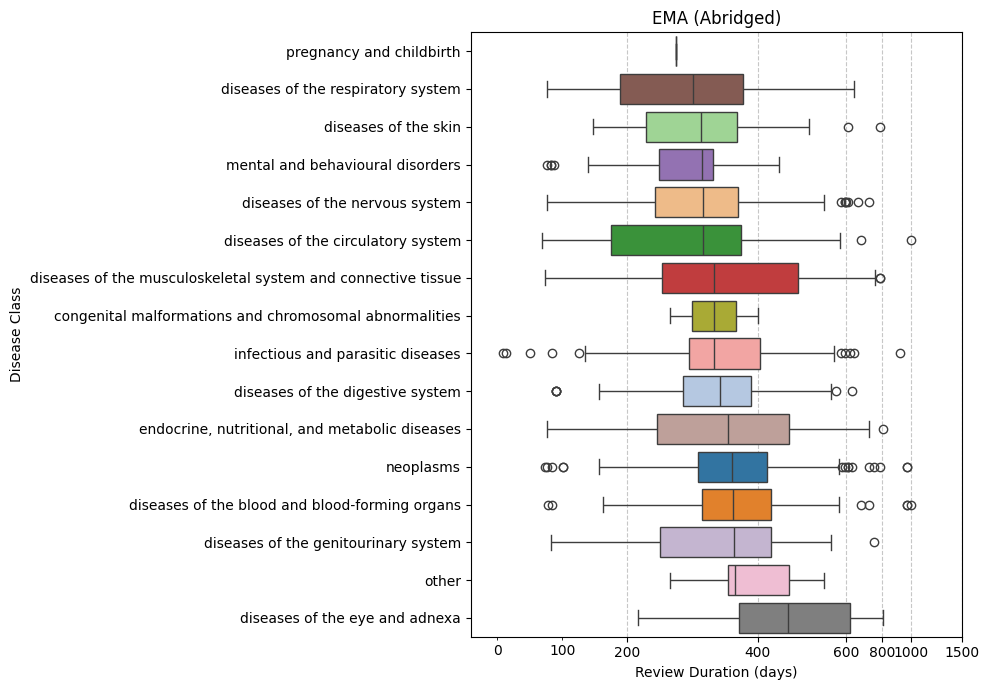

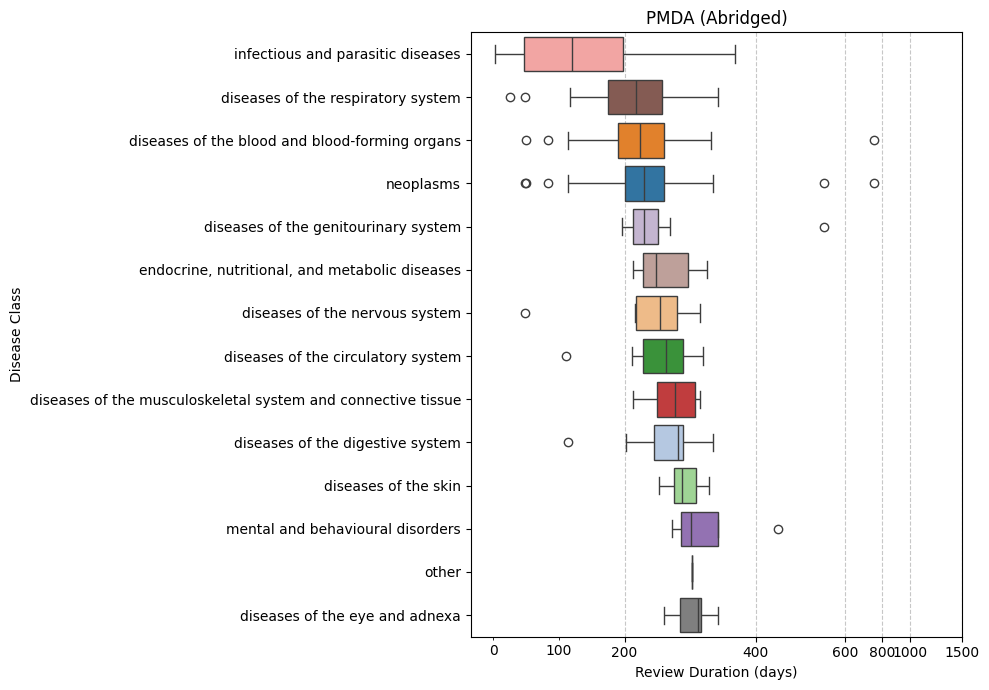

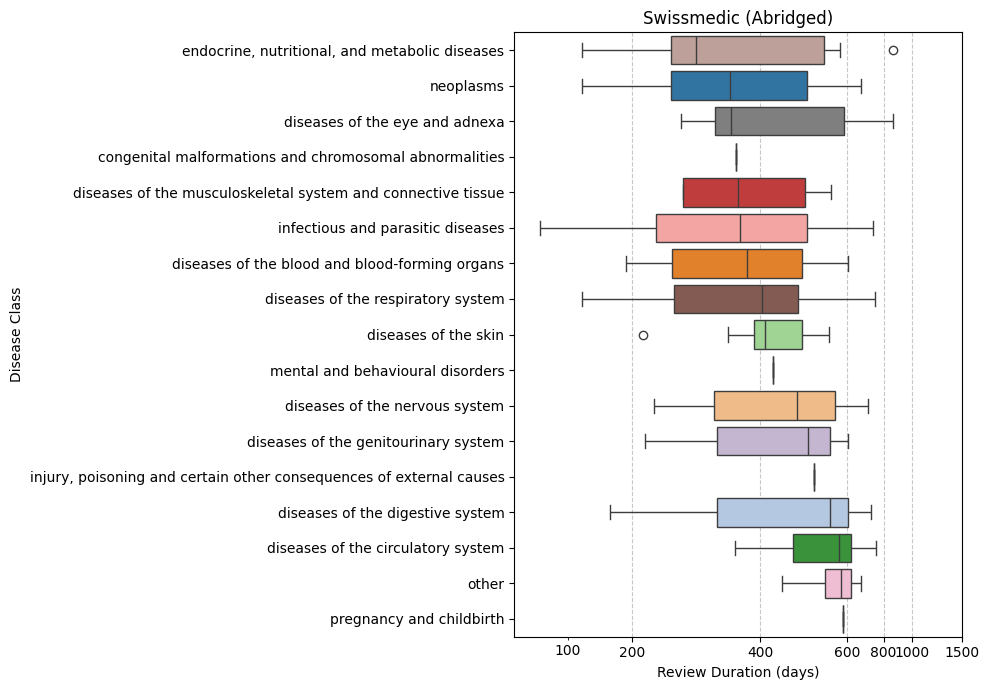

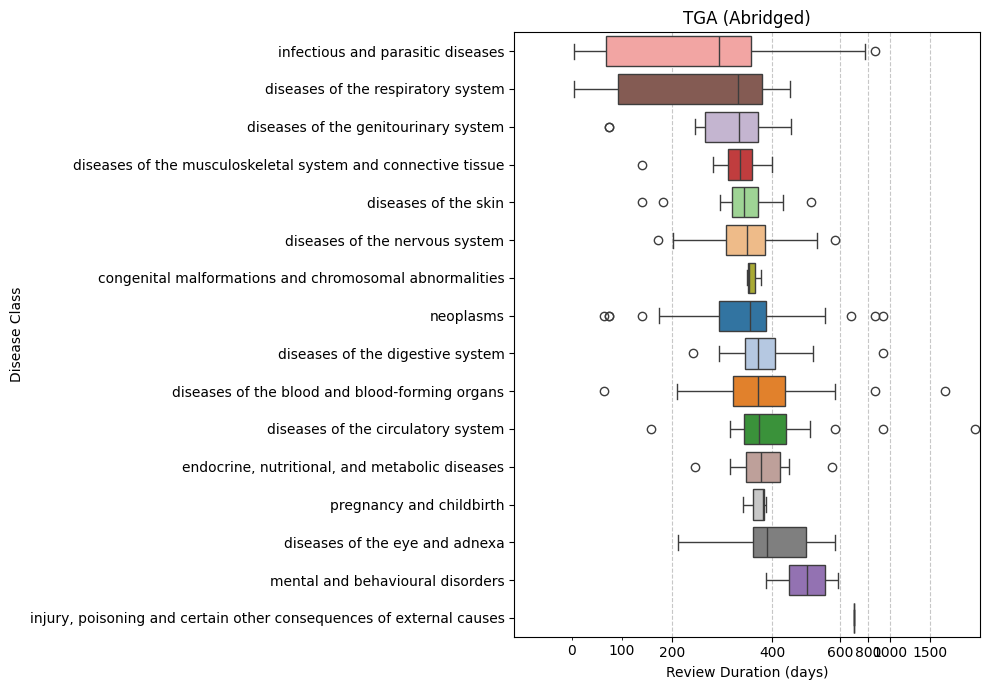

In [335]:
for k,v in DATASETS.items():
    if 'Application_date' in v.columns and 'Decision_date' in v.columns:
        plot_review_duration_by_disease_class(
            v,
            submission_col='Application_date',
            decision_col='Decision_date',
            dataset_name=k,
            disease_class_colormap=disease_class_colormap,
            abridged=True
        )
    else:
        print(f"{k}: 'Application_date' or 'Decision_date' column not found, skipping review duration by agency plot.")

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\863275249.py:736: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, y='Disease_class(es)', x='Review_duration_days',


C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\863275249.py:736: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, y='Disease_class(es)', x='Review_duration_days',
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\863275249.py:736: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, y='Disease_class(es)', x='Review_duration_days',
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\863275249.py:736: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, y='Disease_class(es)', x='Review_duration_days',
C:\User

HealthCanada: 'Application_date' or 'Decision_date' column not found, skipping review duration by agency plot.
FDA: 'Application_date' or 'Decision_date' column not found, skipping review duration by agency plot.


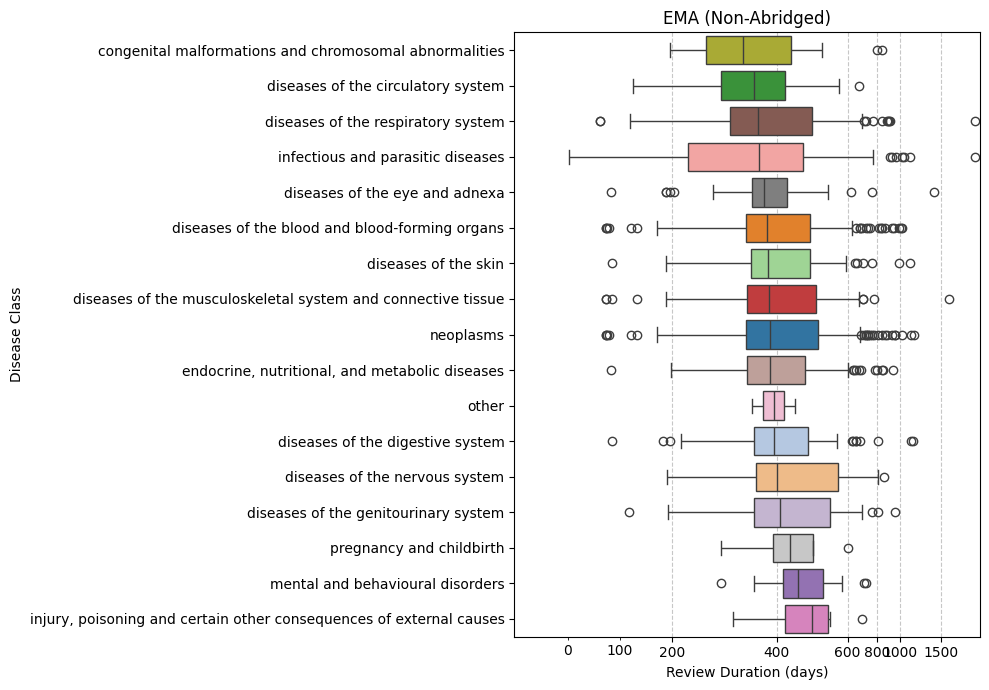

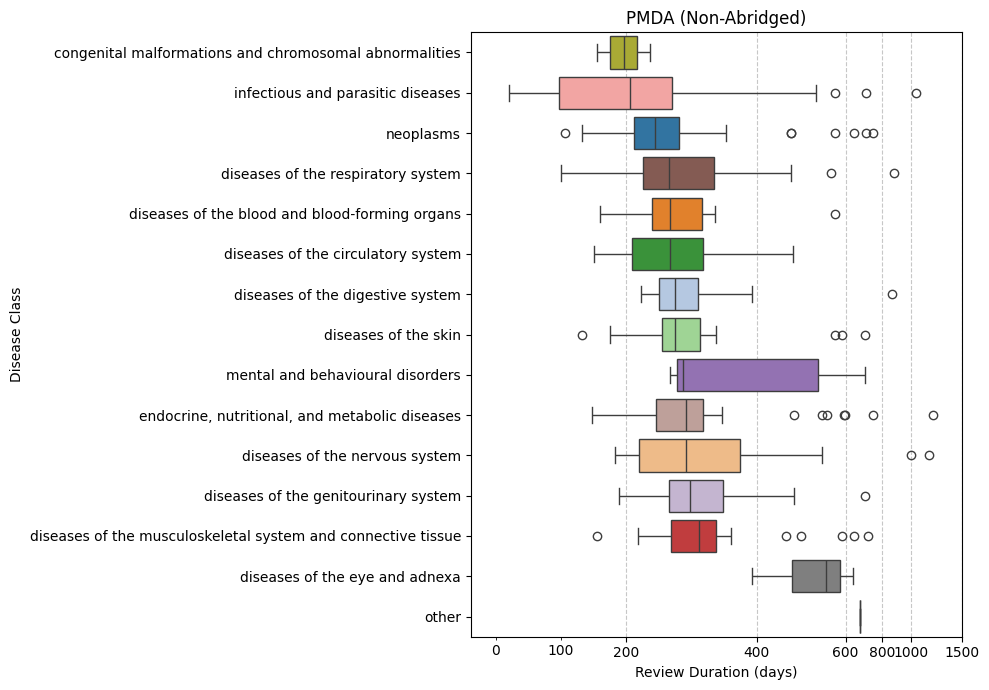

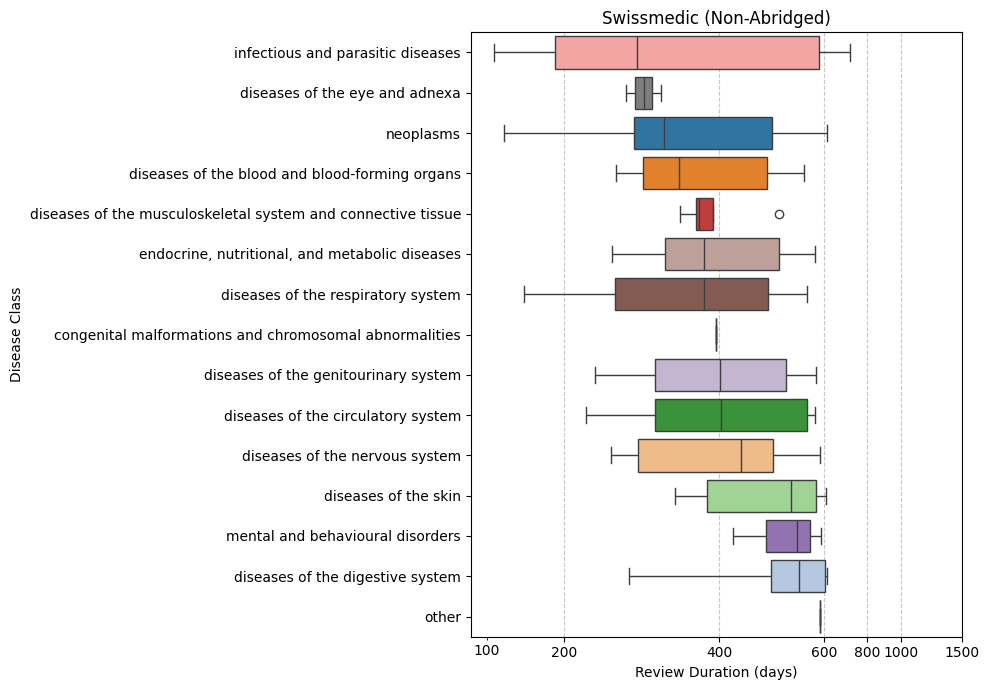

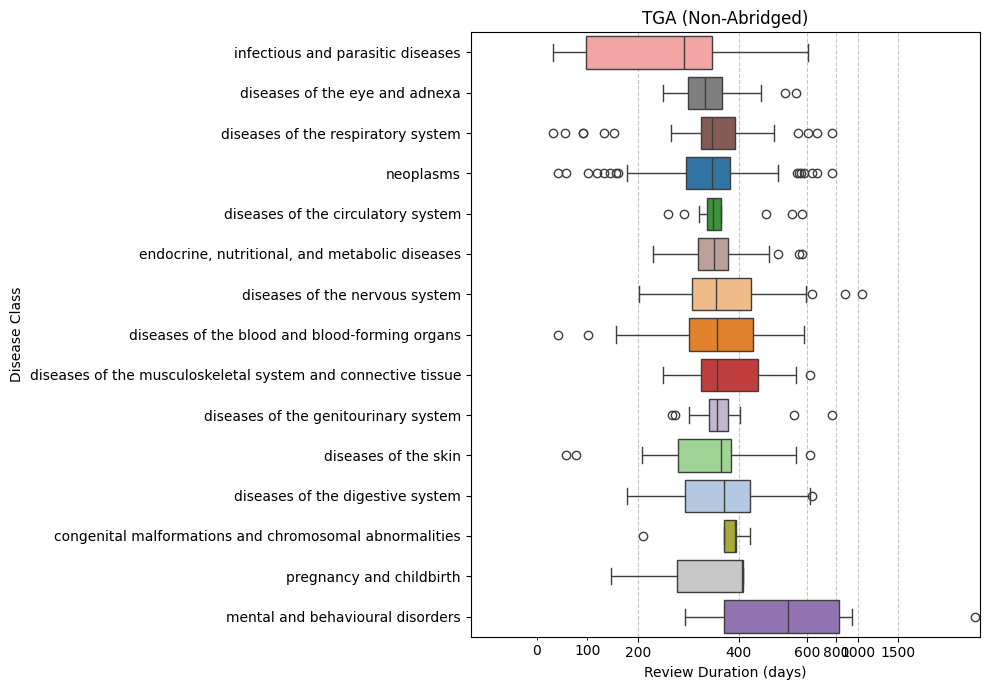

In [336]:
for k,v in DATASETS.items():
    if 'Application_date' in v.columns and 'Decision_date' in v.columns:
        plot_review_duration_by_disease_class(
            v,
            submission_col='Application_date',
            decision_col='Decision_date',
            dataset_name=k,
            disease_class_colormap=disease_class_colormap,
            abridged=False
        )
    else:
        print(f"{k}: 'Application_date' or 'Decision_date' column not found, skipping review duration by agency plot.")

C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\863275249.py:736: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, y='Disease_class(es)', x='Review_duration_days',
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\863275249.py:736: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, y='Disease_class(es)', x='Review_duration_days',
C:\Users\hh25g551\AppData\Local\Temp\ipykernel_33868\863275249.py:736: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, y='Disease_class(es)', x='Review_duration_days',
C:\User

HealthCanada: 'Application_date' or 'Decision_date' column not found, skipping review duration by agency plot.
FDA: 'Application_date' or 'Decision_date' column not found, skipping review duration by agency plot.


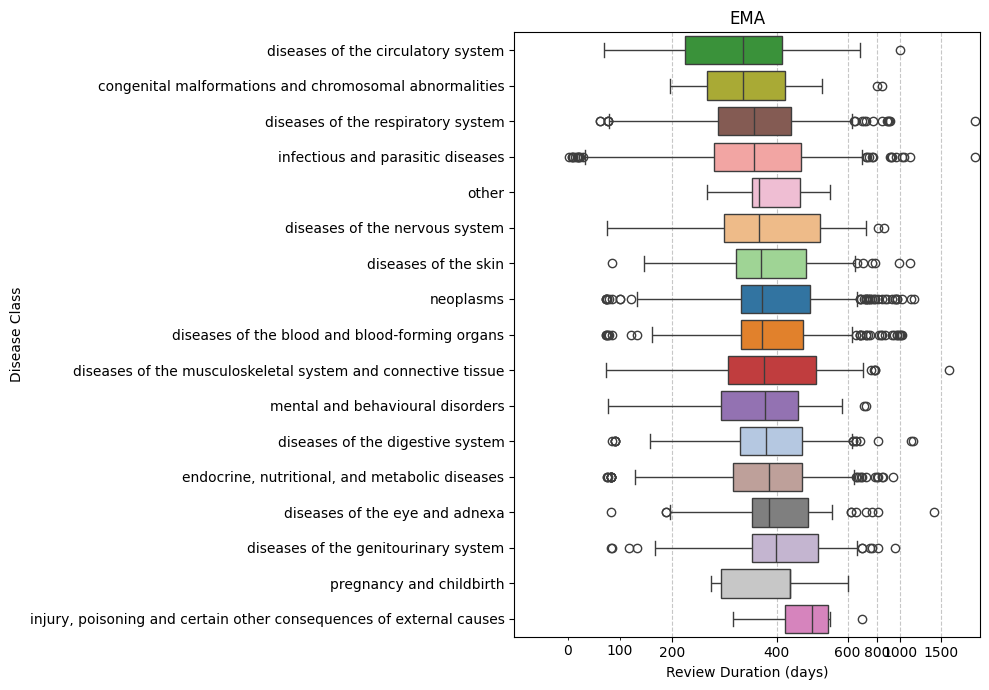

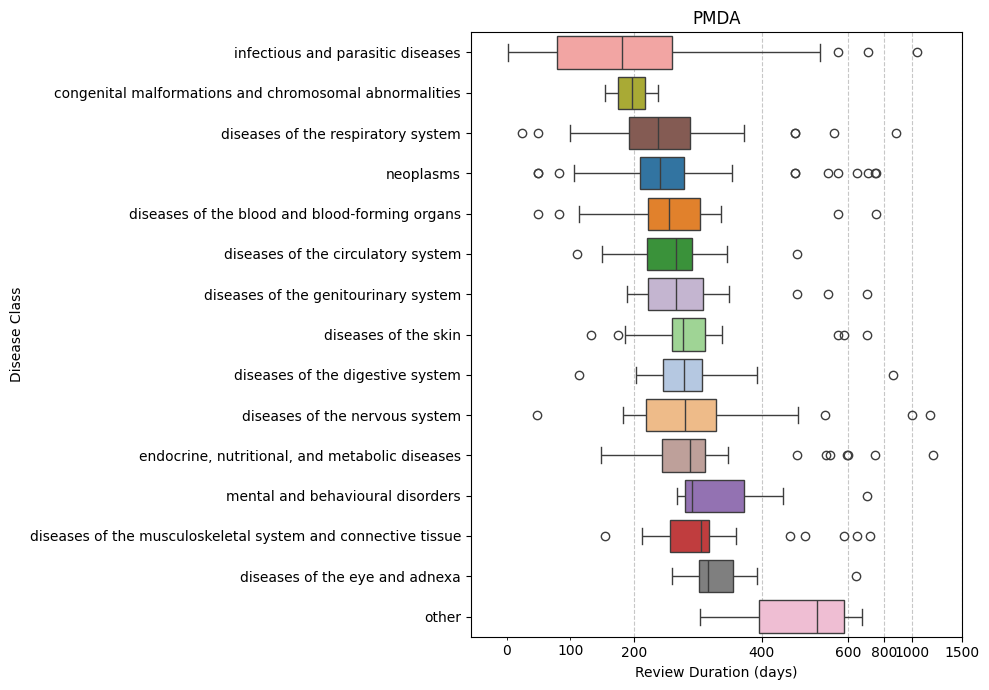

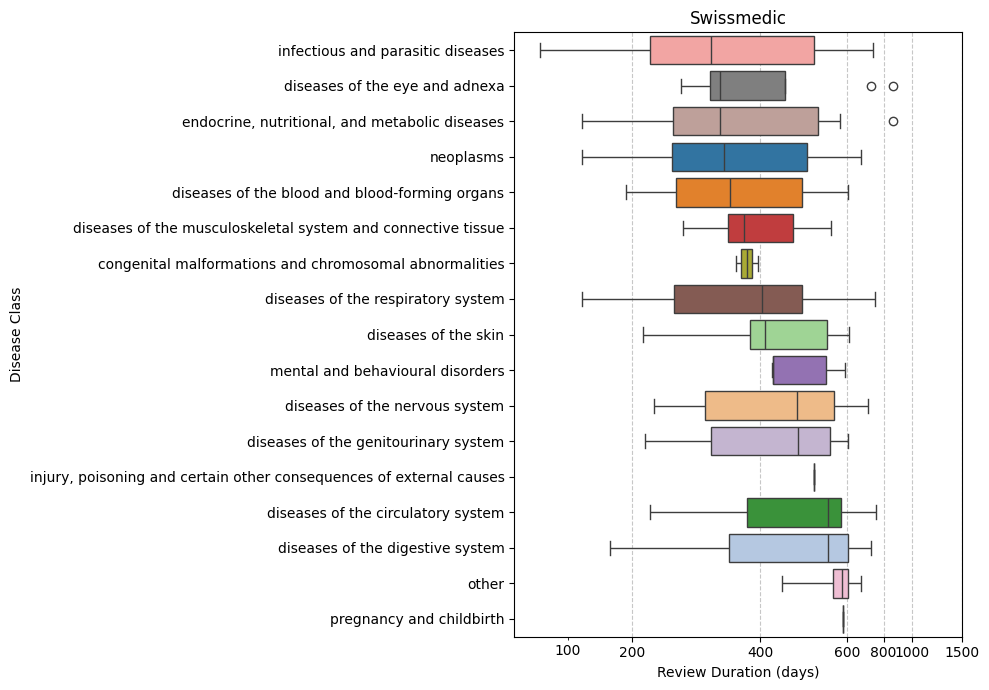

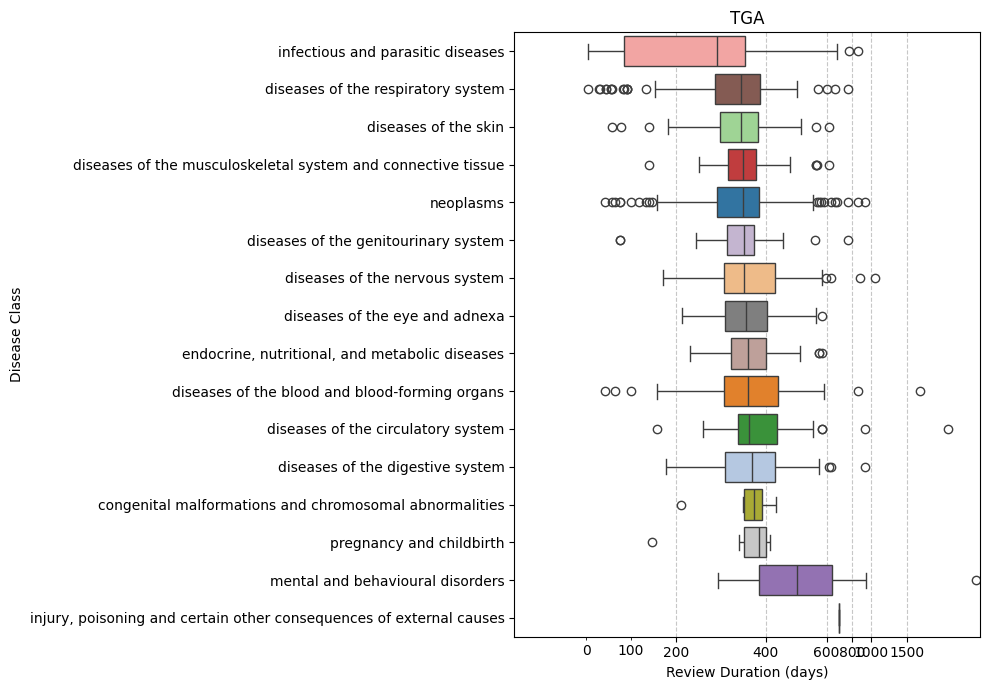

In [337]:
for k,v in DATASETS.items():
    if 'Application_date' in v.columns and 'Decision_date' in v.columns:
        plot_review_duration_by_disease_class(
            v,
            submission_col='Application_date',
            decision_col='Decision_date',
            dataset_name=k,
            disease_class_colormap=disease_class_colormap,
            abridged=None
        )
    else:
        print(f"{k}: 'Application_date' or 'Decision_date' column not found, skipping review duration by agency plot.")

In [338]:
# plot_decision_distribution_by_agency(
#     agency_dfs=DATASETS,
#     dataset_name='combined'
# )

In [339]:
# makes no sense, omit for now: non-approvals are usually invisible and not reported

# for k,v in DATASETS.items():
#     if 'Decision_date' in v.columns and 'Disease_class(es)' in v.columns:
#         plot_decision_breakdown_per_disease_class(
#             v,
#             dataset_name=k,
#             date_col='Decision_date'
#         )
#     else:
#         print(f"{k}: 'Decision_date' or 'Disease_class(es)' column not found, skipping decision breakdown per disease class plot.")

In [340]:
# makes no sense, omit for now: non-approvals are usually invisible and not reported

# for k,v in DATASETS.items():
#     if 'Decision_date' in v.columns:
#         plot_decision_breakdown_per_agency_per_year(
#             v,
#             dataset_name=k,
#             date_col='Decision_date'
#         )
#     else:
#         print(f"{k}: 'Decision_date' column not found, skipping decision breakdown per agency plot.")

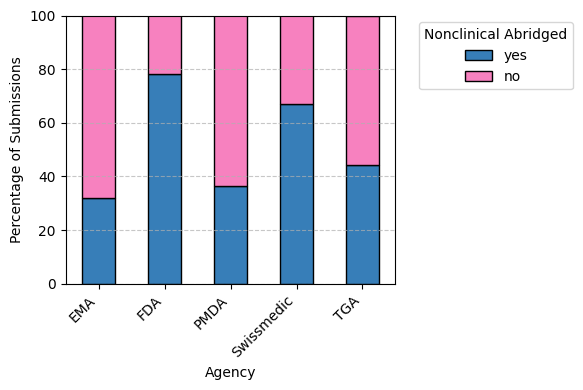

In [341]:
plot_nonclinical_abridged_distribution(
    agency_dfs=DATASETS,
    dataset_name='combined'
)

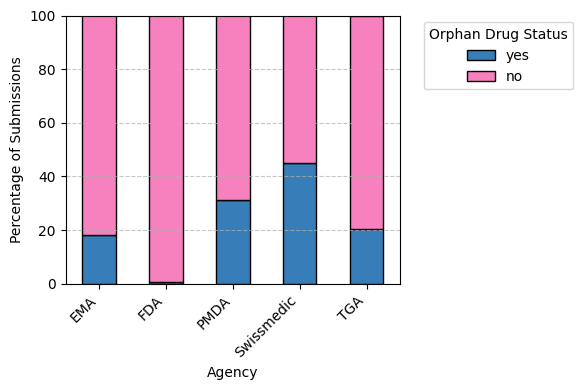

In [342]:
plot_orphan_drug_status_distribution(
    agency_dfs=DATASETS,
    dataset_name='combined'
)

In [343]:
for k,v in DATASETS.items():
    if 'Decision_year' in v.columns:
        plot_all_measures_per_dataset(
            v,
            dataset_name=k,
            date_col='Decision_year'
        )
    else:
        print(f"{k}: 'Decision_year' column not found, skipping all measures for authority plot.")


[OK] ./../inference/combined/figures/deaths_vs_approvals_EMA_Deaths.png
Deaths saved to file.

[OK] ./../inference/combined/figures/dalys_vs_approvals_EMA_DALYs.png
DALYs saved to file.

[OK] ./../inference/combined/figures/dalys_vs_approvals_EMA_DALYs.png
DALYs saved to file.

[OK] ./../inference/combined/figures/incidence_vs_approvals_EMA_Incidence.png
Incidence saved to file.

[OK] ./../inference/combined/figures/incidence_vs_approvals_EMA_Incidence.png
Incidence saved to file.

[OK] ./../inference/combined/figures/prevalence_vs_approvals_EMA_Prevalence.png
Prevalence saved to file.

[OK] ./../inference/combined/figures/prevalence_vs_approvals_EMA_Prevalence.png
Prevalence saved to file.

[OK] ./../inference/combined/figures/deaths_vs_approvals_PMDA_Deaths.png
Deaths saved to file.

[OK] ./../inference/combined/figures/deaths_vs_approvals_PMDA_Deaths.png
Deaths saved to file.

[OK] ./../inference/combined/figures/dalys_vs_approvals_PMDA_DALYs.png
DALYs saved to file.

[OK] ./../infe